In [ ]:
# Step 1 — Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

for folder in ["Uncurated set", "Curated set"]:
    path = f"/content/drive/MyDrive/{folder}"
    print(f"\n{folder}:")
    for item in os.listdir(path):
        print(f"  repr: {repr(item)}")


Uncurated set:
  repr: '1840 Malignant Pics'
  repr: '1840 Benign Pics'

Curated set:
  repr: '1840 Malignant Pics'
  repr: '1840 Benign Pics'


In [ ]:
import os

path = "/content/drive/MyDrive/Uncurated set/1840 Benign Pics"
items = os.listdir(path)
print(f"Total items: {len(items)}")
print("First 10 items:")
for item in items[:10]:
    print(repr(item))

Total items: 1841
First 10 items:
'ISIC_0028836.jpg'
'ISIC_0028875.jpg'
'ISIC_0029037.jpg'
'ISIC_0029046.jpg'
'ISIC_0028953.jpg'
'ISIC_0028844.jpg'
'ISIC_0028794.jpg'
'ISIC_0028867.jpg'
'ISIC_0028983.jpg'
'ISIC_0028887.jpg'


In [ ]:
import os, shutil, random

def split_dataset(source_dir, output_dir, train=0.7, val=0.2, seed=42):
    random.seed(seed)
    for cls_folder, cls_name in [
        ("1840 Benign Pics", "Benign"),
        ("1840 Malignant Pics", "Malignant")
    ]:
        src = os.path.join(source_dir, cls_folder)
        images = [f for f in os.listdir(src)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)

        n_train = int(len(images) * train)
        n_val   = int(len(images) * val)

        splits = {
            'Training':   images[:n_train],
            'Validation': images[n_train:n_train + n_val],
            'Test':       images[n_train + n_val:]
        }

        for split_name, imgs in splits.items():
            dest = os.path.join(output_dir, split_name, cls_name)
            os.makedirs(dest, exist_ok=True)
            for img in imgs:
                shutil.copy(os.path.join(src, img), dest)
            print(f"{split_name}/{cls_name}: {len(imgs)} images")

print("=== Splitting Uncurated Dataset ===")
split_dataset(
    "/content/drive/MyDrive/Uncurated set",
    "/content/drive/MyDrive/dataset_uncurated"
)

print("\n=== Splitting Curated Dataset ===")
split_dataset(
    "/content/drive/MyDrive/Curated set",
    "/content/drive/MyDrive/dataset_curated"
)

print("\nDone!")

=== Splitting Uncurated Dataset ===
Training/Benign: 1286 images
Validation/Benign: 367 images
Test/Benign: 185 images
Training/Malignant: 1287 images
Validation/Malignant: 367 images
Test/Malignant: 185 images

=== Splitting Curated Dataset ===
Training/Benign: 1287 images
Validation/Benign: 367 images
Test/Benign: 185 images
Training/Malignant: 1287 images
Validation/Malignant: 367 images
Test/Malignant: 185 images

Done!


In [ ]:
import shutil, os

print("Copying uncurated dataset to local storage...")
if not os.path.exists("/content/dataset_uncurated"):
    shutil.copytree(
        "/content/drive/MyDrive/dataset_uncurated",
        "/content/dataset_uncurated"
    )
    print("Uncurated done!")
else:
    print("Uncurated already exists!")

print("Copying curated dataset to local storage...")
if not os.path.exists("/content/dataset_curated"):
    shutil.copytree(
        "/content/drive/MyDrive/dataset_curated",
        "/content/dataset_curated"
    )
    print("Curated done!")
else:
    print("Curated already exists!")

Copying uncurated dataset to local storage...
Uncurated done!
Copying curated dataset to local storage...
Curated done!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json

# ─── CONFIG ───────────────────────────────────────────────
base       = "/content/dataset_uncurated"
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 25

# ─── DATA ─────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f"{base}/Training",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_gen = val_datagen.flow_from_directory(
    f"{base}/Validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# ─── CNN ──────────────────────────────────────────────────
model_uncurated = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_uncurated.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_uncurated.summary()

# ─── TRAIN ────────────────────────────────────────────────
history_uncurated = model_uncurated.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

# ─── SAVE ─────────────────────────────────────────────────
model_uncurated.save("/content/drive/MyDrive/cnn_uncurated.keras")
with open("/content/drive/MyDrive/history_uncurated.json", "w") as f:
    json.dump(history_uncurated.history, f)

print("\nDone! Uncurated model saved to Drive.")


Found 2965 images belonging to 2 classes.
Found 1038 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,153 (17.49 MB)

 Trainable params: 4,584,193 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 60s 533ms/step - accuracy: 0.7042 - loss: 0.6948 - val_accuracy: 0.3536 - val_loss: 3.3050
Epoch 2/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 38s 406ms/step - accuracy: 0.7646 - loss: 0.4860 - val_accuracy: 0.3536 - val_loss: 5.8894
Epoch 3/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 37s 397ms/step - accuracy: 0.7771 - loss: 0.4595 - val_accuracy: 0.3536 - val_loss: 4.1067
Epoch 4/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 37s 403ms/step - accuracy: 0.7902 - loss: 0.4514 - val_accuracy: 0.4499 - val_loss: 1.4862
Epoch 5/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 35s 380ms/step - accuracy: 0.7841 - loss: 0.4536 - val_accuracy: 0.6599 - val_loss: 0.6897
Epoch 6/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 37s 397ms/step - accuracy: 0.7855 - loss: 0.4439 - val_accuracy: 0.7312 - val_loss: 0.6026
Epoch 7/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 37s 397ms/step - accuracy: 0.8057 - loss: 0.4268 - val_accuracy: 0.8170 - val_loss: 0.4071
Epoch 8/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 37s 402ms/step - accuracy: 0.8054 - loss: 0.4117 - val_accu

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json

base       = "/content/dataset_curated"
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 25

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen_c = train_datagen.flow_from_directory(
    f"{base}/Training",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_gen_c = val_datagen.flow_from_directory(
    f"{base}/Validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

model_curated = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_curated.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_curated = model_curated.fit(
    train_gen_c,
    validation_data=val_gen_c,
    epochs=EPOCHS
)

model_curated.save("/content/drive/MyDrive/cnn_curated.keras")
with open("/content/drive/MyDrive/history_curated.json", "w") as f:
    json.dump(history_curated.history, f)

print("\nDone! Curated model saved to Drive.")

Found 2955 images belonging to 2 classes.
Found 976 images belonging to 2 classes.
Epoch 1/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 87s 865ms/step - accuracy: 0.6829 - loss: 0.7661 - val_accuracy: 0.6240 - val_loss: 0.7041
Epoch 2/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 77s 823ms/step - accuracy: 0.7310 - loss: 0.5420 - val_accuracy: 0.6240 - val_loss: 1.1369
Epoch 3/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 73s 788ms/step - accuracy: 0.7455 - loss: 0.5162 - val_accuracy: 0.6240 - val_loss: 1.4787
Epoch 4/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 70s 758ms/step - accuracy: 0.7692 - loss: 0.4911 - val_accuracy: 0.6629 - val_loss: 0.7934
Epoch 5/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 72s 780ms/step - accuracy: 0.7665 - loss: 0.4880 - val_accuracy: 0.6895 - val_loss: 0.8505
Epoch 6/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 77s 824ms/step - accuracy: 0.7601 - loss: 0.4829 - val_accuracy: 0.7756 - val_loss: 0.5070
Epoch 7/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 70s 752ms/step - accuracy: 0.7800 - loss: 0.4728 - val_accuracy: 0.7838 - val_loss: 0.4532
Epoch 8/25
93/

In [ ]:
MODEL_PATH  = "/content/drive/MyDrive/cnn_curated.keras"
TEST_DIR    = "/content/dataset_curated/Test"

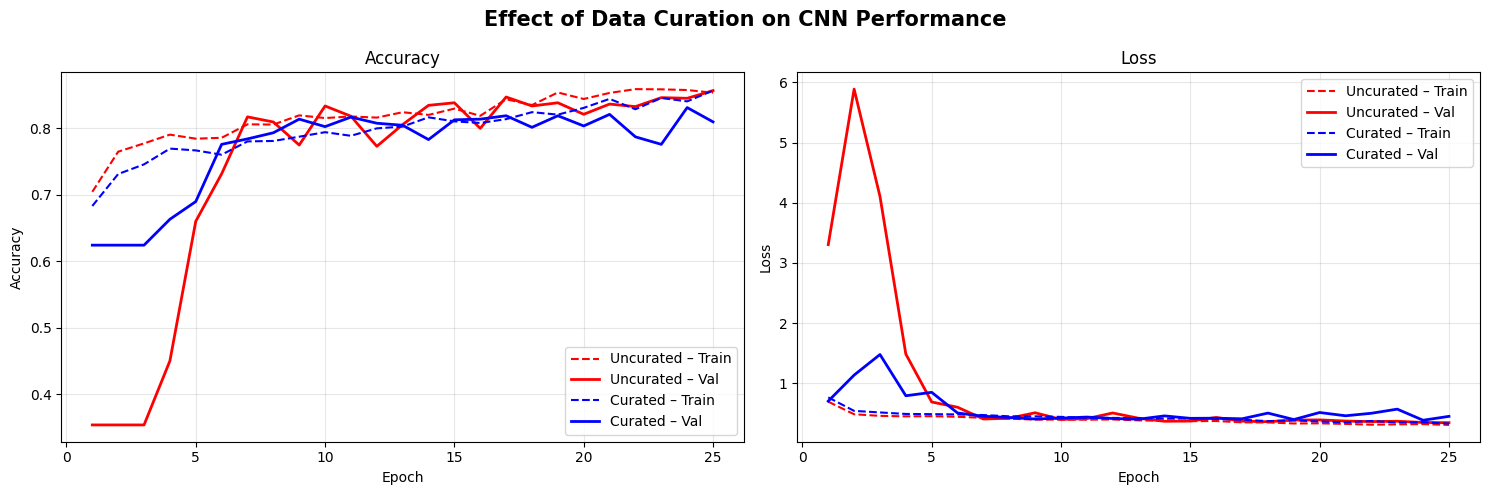

Saved!


In [ ]:
import json, matplotlib.pyplot as plt

with open("/content/drive/MyDrive/history_uncurated.json") as f:
    h_unc = json.load(f)
with open("/content/drive/MyDrive/history_curated.json") as f:
    h_cur = json.load(f)

epochs = range(1, 26)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Effect of Data Curation on CNN Performance", fontsize=15, fontweight='bold')

# Accuracy
ax = axes[0]
ax.plot(epochs, h_unc['accuracy'],     'r--', linewidth=1.5, label='Uncurated – Train')
ax.plot(epochs, h_unc['val_accuracy'], 'r-',  linewidth=2,   label='Uncurated – Val')
ax.plot(epochs, h_cur['accuracy'],     'b--', linewidth=1.5, label='Curated – Train')
ax.plot(epochs, h_cur['val_accuracy'], 'b-',  linewidth=2,   label='Curated – Val')
ax.set_title('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Loss
ax = axes[1]
ax.plot(epochs, h_unc['loss'],     'r--', linewidth=1.5, label='Uncurated – Train')
ax.plot(epochs, h_unc['val_loss'], 'r-',  linewidth=2,   label='Uncurated – Val')
ax.plot(epochs, h_cur['loss'],     'b--', linewidth=1.5, label='Curated – Train')
ax.plot(epochs, h_cur['val_loss'], 'b-',  linewidth=2,   label='Curated – Val')
ax.set_title('Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/curated_vs_uncurated.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

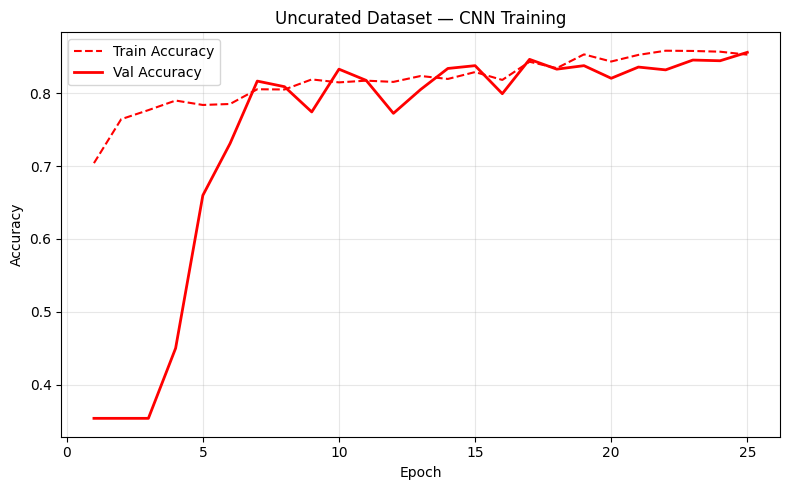

Uncurated plot saved!


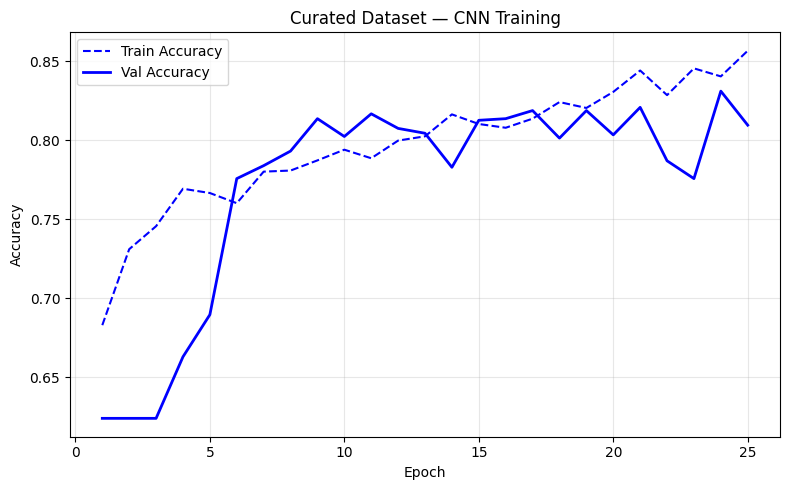

Curated plot saved!


In [ ]:
import json, matplotlib.pyplot as plt

with open("/content/drive/MyDrive/history_uncurated.json") as f:
    h_unc = json.load(f)
with open("/content/drive/MyDrive/history_curated.json") as f:
    h_cur = json.load(f)

epochs = range(1, 26)

# ── Plot 1 — Uncurated ────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(epochs, h_unc['accuracy'],     'r--', linewidth=1.5, label='Train Accuracy')
plt.plot(epochs, h_unc['val_accuracy'], 'r-',  linewidth=2,   label='Val Accuracy')
plt.title('Uncurated Dataset — CNN Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/uncurated_results.png", dpi=150)
plt.show()
print("Uncurated plot saved!")

# ── Plot 2 — Curated ──────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(epochs, h_cur['accuracy'],     'b--', linewidth=1.5, label='Train Accuracy')
plt.plot(epochs, h_cur['val_accuracy'], 'b-',  linewidth=2,   label='Val Accuracy')
plt.title('Curated Dataset — CNN Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/curated_results.png", dpi=150)
plt.show()
print("Curated plot saved!")

In [ ]:
import shutil, os

print("Copying uncurated dataset...")
if not os.path.exists("/content/dataset_uncurated"):
    shutil.copytree(
        "/content/drive/MyDrive/dataset_uncurated",
        "/content/dataset_uncurated"
    )
    print("Uncurated done!")
else:
    print("Uncurated already exists!")

print("Copying curated dataset...")
if not os.path.exists("/content/dataset_curated"):
    shutil.copytree(
        "/content/drive/MyDrive/dataset_curated",
        "/content/dataset_curated"
    )
    print("Curated done!")
else:
    print("Curated already exists!")

Copying uncurated dataset...
Uncurated done!
Copying curated dataset...
Curated done!


Found 533 images belonging to 2 classes.
Found 514 images belonging to 2 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step

Uncurated Dataset
Accuracy:    84.80%
Sensitivity: 90.80%  (malignant recall)
Specificity: 73.51%  (benign recall)
Precision:   86.58%
F1 Score:    0.8864

TN: 136  FP: 49  FN: 32  TP: 316


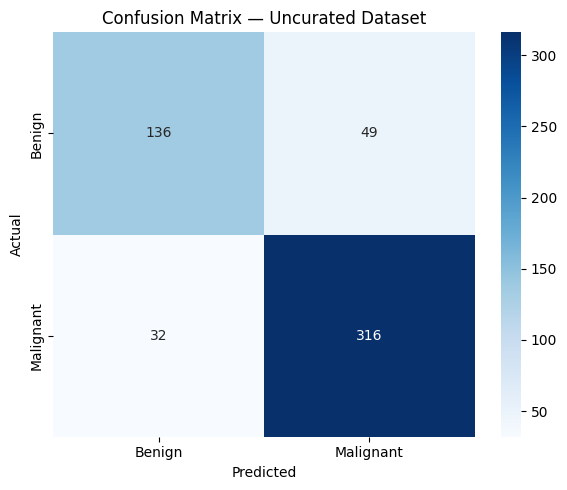

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 629ms/step

Curated Dataset
Accuracy:    79.38%
Sensitivity: 63.24%  (malignant recall)
Specificity: 88.45%  (benign recall)
Precision:   75.48%
F1 Score:    0.6882

TN: 291  FP: 38  FN: 68  TP: 117


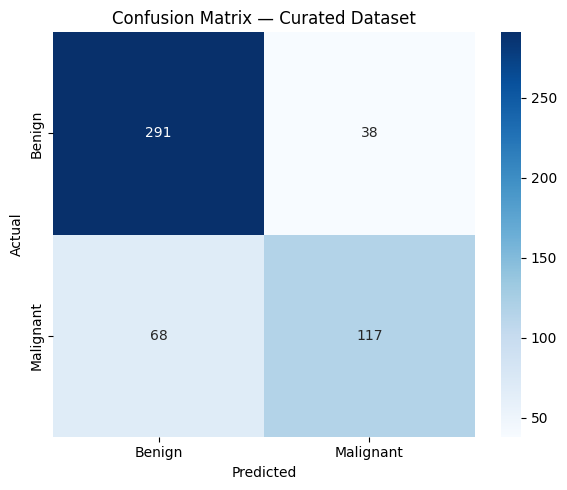


Metric                          Uncurated              Curated
Accuracy                           84.80%               79.38%
Sensitivity                        90.80%               63.24%
Specificity                        73.51%               88.45%
Precision                          86.58%               75.48%
F1 Score                           0.8864               0.6882
True Negatives                        136                  291
False Positives                        49                   38
False Negatives                        32                   68
True Positives                        316                  117


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ─── LOAD MODELS ──────────────────────────────────────────
model_unc = load_model("/content/drive/MyDrive/cnn_uncurated.keras")
model_cur = load_model("/content/drive/MyDrive/cnn_curated.keras")

# ─── TEST DATA ────────────────────────────────────────────
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen_unc = test_datagen.flow_from_directory(
    "/content/dataset_uncurated/Test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_gen_cur = test_datagen.flow_from_directory(
    "/content/dataset_curated/Test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ─── EVALUATE FUNCTION ────────────────────────────────────
def evaluate_model(model, test_gen, label):
    loss, accuracy = model.evaluate(test_gen, verbose=0)
    predictions = (model.predict(test_gen) > 0.5).astype(int).flatten()
    true_labels  = test_gen.classes
    class_names  = list(test_gen.class_indices.keys())

    cm = confusion_matrix(true_labels, predictions)
    tn, fp, fn, tp = cm.ravel()

    sensitivity  = tp / (tp + fn)
    specificity  = tn / (tn + fp)
    precision    = tp / (tp + fp)
    f1           = 2 * (precision * sensitivity) / (precision + sensitivity)

    print(f"\n{'='*40}")
    print(f"{label}")
    print(f"{'='*40}")
    print(f"Accuracy:    {accuracy*100:.2f}%")
    print(f"Sensitivity: {sensitivity*100:.2f}%  (malignant recall)")
    print(f"Specificity: {specificity*100:.2f}%  (benign recall)")
    print(f"Precision:   {precision*100:.2f}%")
    print(f"F1 Score:    {f1:.4f}")
    print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

    # Confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Confusion Matrix — {label}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/cm_{label.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

    return {
        'label': label,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

# ─── RUN BOTH ─────────────────────────────────────────────
results_unc = evaluate_model(model_unc, test_gen_unc, "Uncurated Dataset")
results_cur = evaluate_model(model_cur, test_gen_cur, "Curated Dataset")

# ─── SUMMARY TABLE ────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Metric':<20} {'Uncurated':>20} {'Curated':>20}")
print("="*70)
print(f"{'Accuracy':<20} {results_unc['accuracy']*100:>19.2f}% {results_cur['accuracy']*100:>19.2f}%")
print(f"{'Sensitivity':<20} {results_unc['sensitivity']*100:>19.2f}% {results_cur['sensitivity']*100:>19.2f}%")
print(f"{'Specificity':<20} {results_unc['specificity']*100:>19.2f}% {results_cur['specificity']*100:>19.2f}%")
print(f"{'Precision':<20} {results_unc['precision']*100:>19.2f}% {results_cur['precision']*100:>19.2f}%")
print(f"{'F1 Score':<20} {results_unc['f1']:>20.4f} {results_cur['f1']:>20.4f}")
print(f"{'True Negatives':<20} {results_unc['tn']:>20} {results_cur['tn']:>20}")
print(f"{'False Positives':<20} {results_unc['fp']:>20} {results_cur['fp']:>20}")
print(f"{'False Negatives':<20} {results_unc['fn']:>20} {results_cur['fn']:>20}")
print(f"{'True Positives':<20} {results_unc['tp']:>20} {results_cur['tp']:>20}")
print("="*70)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K

# ─── DEFINE ALL CUSTOM FUNCTIONS ──────────────────────────
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred, smooth=1e-6):
    return 1 - dice_coef(y_true, y_pred, smooth)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred > 0.5, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# ─── LOAD MODEL ───────────────────────────────────────────
unet = load_model(
    "/content/drive/MyDrive/unet_model.keras",
    custom_objects={
        "combined_loss": combined_loss,
        "dice_coef": dice_coef,
        "dice_loss": dice_loss,
        "iou_score": iou_score
    }
)

print("Model loaded successfully!")
unet.summary()

Model loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 24 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d_8[0][0]  

 Total params: 943,108 (3.60 MB)

 Trainable params: 471,553 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 471,555 (1.80 MB)

All models loaded!


Saving ISIC_0000314.jpg to ISIC_0000314.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step


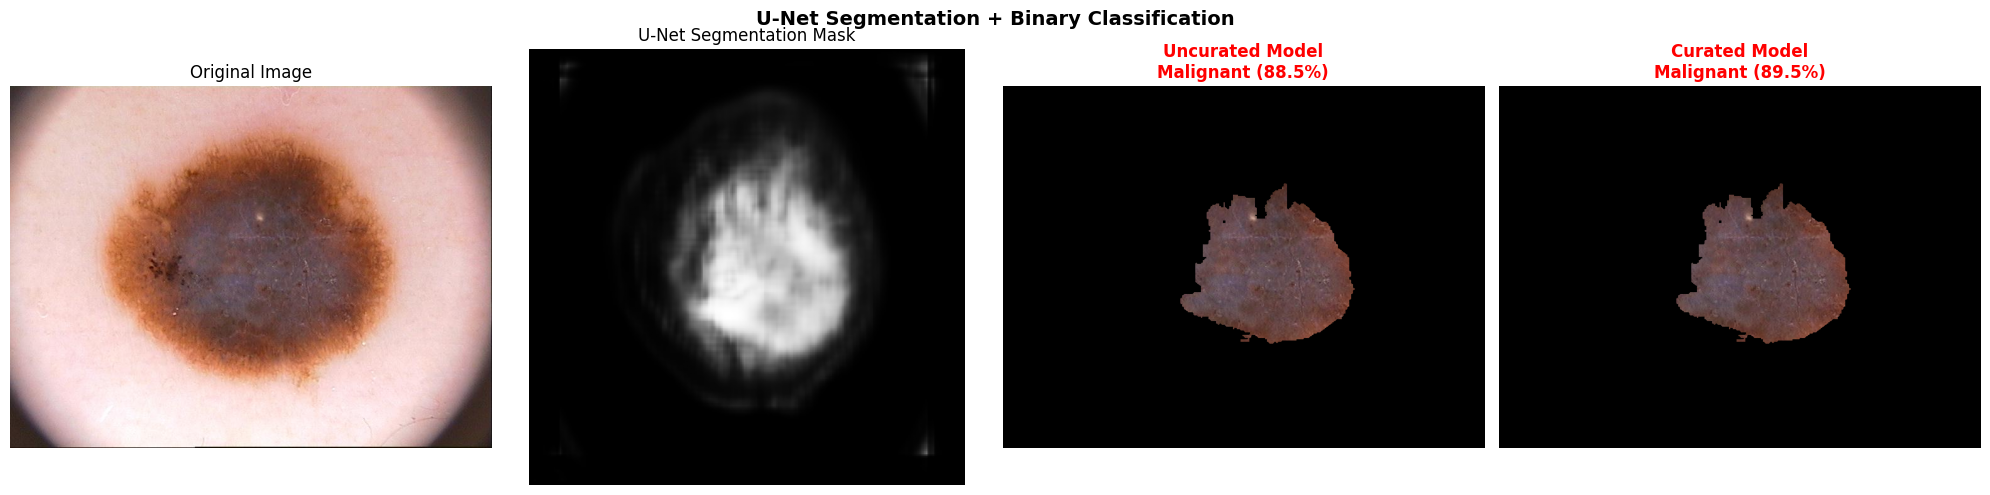


Uncurated Model: Malignant (88.5% confidence)
Curated Model:   Malignant (89.5% confidence)


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from google.colab import files
import tensorflow.keras.backend as K
import tensorflow as tf
import cv2

# ─── CUSTOM FUNCTIONS ─────────────────────────────────────
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred, smooth=1e-6):
    return 1 - dice_coef(y_true, y_pred, smooth)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred > 0.5, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# ─── LOAD ALL MODELS ──────────────────────────────────────
unet = load_model(
    "/content/drive/MyDrive/unet_model.keras",
    custom_objects={
        "combined_loss": combined_loss,
        "dice_coef": dice_coef,
        "dice_loss": dice_loss,
        "iou_score": iou_score
    }
)
model_unc = load_model("/content/drive/MyDrive/cnn_uncurated.keras")
model_cur = load_model("/content/drive/MyDrive/cnn_curated.keras")
print("All models loaded!")

# ─── UPLOAD IMAGE ─────────────────────────────────────────
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ─── STEP 1 — SEGMENT WITH U-NET ──────────────────────────
orig_img = cv2.imread(img_path)
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

unet_input = cv2.resize(orig_img, (256, 256)) / 255.0
unet_input = np.expand_dims(unet_input, axis=0)

mask = unet.predict(unet_input)[0, :, :, 0]
mask_binary = (mask > 0.5).astype(np.uint8)

masked_img = orig_img.copy()
mask_resized = cv2.resize(mask_binary, (orig_img.shape[1], orig_img.shape[0]))
masked_img[mask_resized == 0] = 0

# ─── STEP 2 — CLASSIFY WITH BOTH MODELS ──────────────────
cnn_input = cv2.resize(masked_img, (128, 128)) / 255.0
cnn_input = np.expand_dims(cnn_input, axis=0)

# Uncurated
score_unc = float(model_unc.predict(cnn_input)[0][0])
label_unc = "Malignant" if score_unc > 0.5 else "Benign"
conf_unc  = score_unc * 100 if score_unc > 0.5 else (1 - score_unc) * 100
colour_unc = "red" if label_unc == "Malignant" else "green"

# Curated
score_cur = float(model_cur.predict(cnn_input)[0][0])
label_cur = "Malignant" if score_cur > 0.5 else "Benign"
conf_cur  = score_cur * 100 if score_cur > 0.5 else (1 - score_cur) * 100
colour_cur = "red" if label_cur == "Malignant" else "green"

# ─── DISPLAY ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(orig_img)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title("U-Net Segmentation Mask")
axes[1].axis('off')

axes[2].imshow(masked_img)
axes[2].set_title(f"Uncurated Model\n{label_unc} ({conf_unc:.1f}%)",
                  color=colour_unc, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(masked_img)
axes[3].set_title(f"Curated Model\n{label_cur} ({conf_cur:.1f}%)",
                  color=colour_cur, fontweight='bold')
axes[3].axis('off')

plt.suptitle("U-Net Segmentation + Binary Classification", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/unet_both_models.png", dpi=150)
plt.show()

print(f"\nUncurated Model: {label_unc} ({conf_unc:.1f}% confidence)")
print(f"Curated Model:   {label_cur} ({conf_cur:.1f}% confidence)")

=== Training on Uncurated Dataset ===
Found 2965 images belonging to 2 classes.
Found 1038 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 64s 568ms/step - accuracy: 0.7076 - loss: 0.6890 - val_accuracy: 0.3536 - val_loss: 2.4145
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 40s 430ms/step - accuracy: 0.7734 - loss: 0.4964 - val_accuracy: 0.3536 - val_loss: 3.7379
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 418ms/step - accuracy: 0.7835 - loss: 0.4655 - val_accuracy: 0.3536 - val_loss: 3.1412
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 37s 403ms/step - accuracy: 0.7892 - loss: 0.4474 - val_accuracy: 0.5617 - val_loss: 1.2496
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 419ms/step - accuracy: 0.7926 - loss: 0.4396 - val_accuracy: 0.7062 - val_loss: 0.6184
Epoch 6/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 422ms/step - accuracy: 0.7943 - loss: 0.4257 - val_accuracy: 0.8179 - val_loss: 0.4255
Epoch 7/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 38s 407ms/step - accuracy: 0.8037 - loss: 0.4238 - val_accuracy: 0.8025 - val_loss: 0.4235
Epoch 8/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 422ms/step - accuracy: 0.8054 - loss: 0.4151 - val_accu

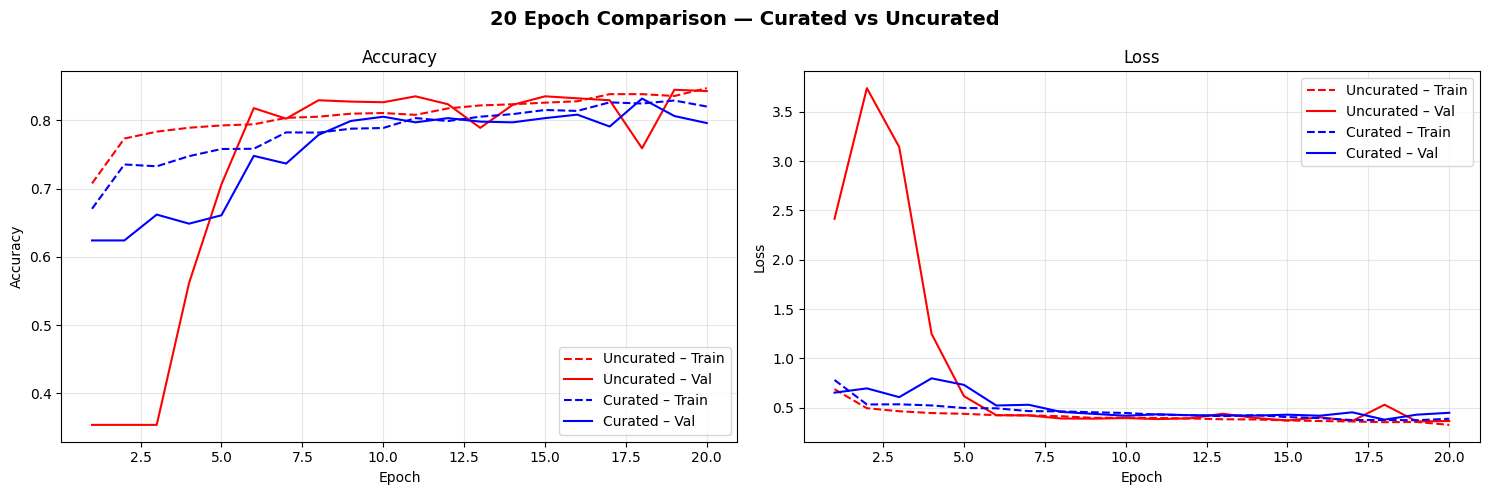

Plot saved!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json, matplotlib.pyplot as plt

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 20

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(128, 128, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ─── UNCURATED ────────────────────────────────────────────
print("=== Training on Uncurated Dataset ===")
train_gen_unc = train_datagen.flow_from_directory(
    "/content/dataset_uncurated/Training",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
val_gen_unc = val_datagen.flow_from_directory(
    "/content/dataset_uncurated/Validation",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
model_unc_20 = build_cnn()
history_unc_20 = model_unc_20.fit(
    train_gen_unc, validation_data=val_gen_unc, epochs=EPOCHS
)
model_unc_20.save("/content/drive/MyDrive/cnn_uncurated_20.keras")
with open("/content/drive/MyDrive/history_uncurated_20.json", "w") as f:
    json.dump(history_unc_20.history, f)
print("Uncurated 20 epoch model saved!")

# ─── CURATED ──────────────────────────────────────────────
print("\n=== Training on Curated Dataset ===")
train_gen_cur = train_datagen.flow_from_directory(
    "/content/dataset_curated/Training",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
val_gen_cur = val_datagen.flow_from_directory(
    "/content/dataset_curated/Validation",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
model_cur_20 = build_cnn()
history_cur_20 = model_cur_20.fit(
    train_gen_cur, validation_data=val_gen_cur, epochs=EPOCHS
)
model_cur_20.save("/content/drive/MyDrive/cnn_curated_20.keras")
with open("/content/drive/MyDrive/history_curated_20.json", "w") as f:
    json.dump(history_cur_20.history, f)
print("Curated 20 epoch model saved!")

# ─── PLOT COMPARISON ──────────────────────────────────────
epochs = range(1, 21)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("20 Epoch Comparison — Curated vs Uncurated", fontsize=14, fontweight='bold')

axes[0].plot(epochs, history_unc_20.history['accuracy'],     'r--', label='Uncurated – Train')
axes[0].plot(epochs, history_unc_20.history['val_accuracy'], 'r-',  label='Uncurated – Val')
axes[0].plot(epochs, history_cur_20.history['accuracy'],     'b--', label='Curated – Train')
axes[0].plot(epochs, history_cur_20.history['val_accuracy'], 'b-',  label='Curated – Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history_unc_20.history['loss'],     'r--', label='Uncurated – Train')
axes[1].plot(epochs, history_unc_20.history['val_loss'], 'r-',  label='Uncurated – Val')
axes[1].plot(epochs, history_cur_20.history['loss'],     'b--', label='Curated – Train')
axes[1].plot(epochs, history_cur_20.history['val_loss'], 'b-',  label='Curated – Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/comparison_20epochs.png", dpi=150)
plt.show()
print("Plot saved!")

Found 533 images belonging to 2 classes.
Found 514 images belonging to 2 classes.


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step

Uncurated 20 Epochs
Accuracy:    83.11%
Sensitivity: 90.80%
Specificity: 68.65%
Precision:   84.49%
F1 Score:    0.8753

TN: 127  FP: 58  FN: 32  TP: 316


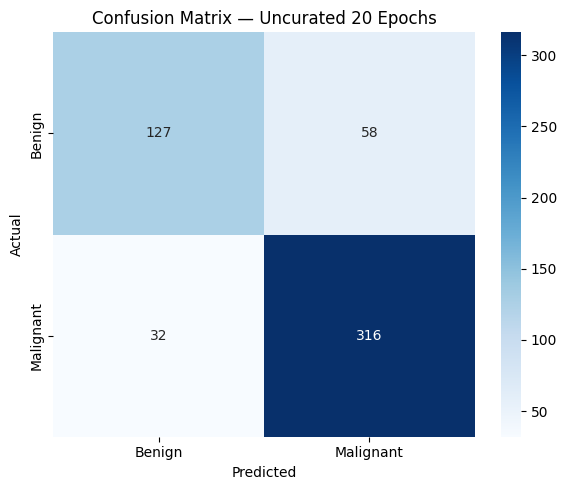

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 553ms/step

Curated 20 Epochs
Accuracy:    79.96%
Sensitivity: 61.08%
Specificity: 90.58%
Precision:   78.47%
F1 Score:    0.6869

TN: 298  FP: 31  FN: 72  TP: 113


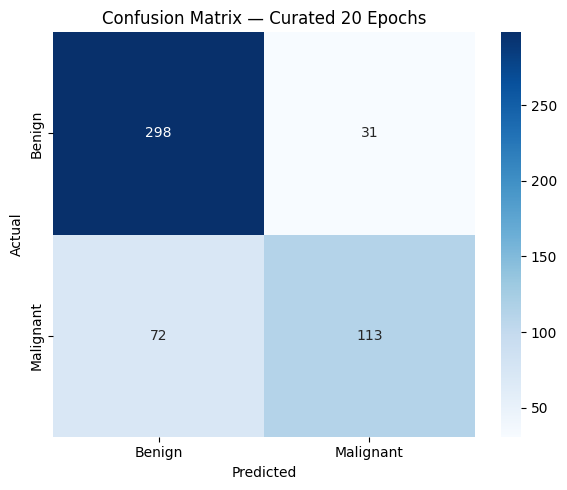


Metric                     Uncurated (20)         Curated (20)
Accuracy                           83.11%               79.96%
Sensitivity                        90.80%               61.08%
Specificity                        68.65%               90.58%
Precision                          84.49%               78.47%
F1 Score                           0.8753               0.6869
True Negatives                        127                  298
False Positives                        58                   31
False Negatives                        32                   72
True Positives                        316                  113


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import tensorflow.keras.backend as K

# ─── LOAD MODELS ──────────────────────────────────────────
model_unc_20 = load_model("/content/drive/MyDrive/cnn_uncurated_20.keras")
model_cur_20 = load_model("/content/drive/MyDrive/cnn_curated_20.keras")

# ─── TEST DATA ────────────────────────────────────────────
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen_unc = test_datagen.flow_from_directory(
    "/content/dataset_uncurated/Test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)
test_gen_cur = test_datagen.flow_from_directory(
    "/content/dataset_curated/Test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ─── EVALUATE FUNCTION ────────────────────────────────────
def evaluate_model(model, test_gen, label):
    loss, accuracy = model.evaluate(test_gen, verbose=0)
    predictions = (model.predict(test_gen) > 0.5).astype(int).flatten()
    true_labels  = test_gen.classes
    class_names  = list(test_gen.class_indices.keys())

    cm = confusion_matrix(true_labels, predictions)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision   = tp / (tp + fp)
    f1          = 2 * (precision * sensitivity) / (precision + sensitivity)

    print(f"\n{'='*40}")
    print(f"{label}")
    print(f"{'='*40}")
    print(f"Accuracy:    {accuracy*100:.2f}%")
    print(f"Sensitivity: {sensitivity*100:.2f}%")
    print(f"Specificity: {specificity*100:.2f}%")
    print(f"Precision:   {precision*100:.2f}%")
    print(f"F1 Score:    {f1:.4f}")
    print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

    # Confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Confusion Matrix — {label}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/cm_20epoch_{label.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

    return {
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

# ─── RUN BOTH ─────────────────────────────────────────────
results_unc = evaluate_model(model_unc_20, test_gen_unc, "Uncurated 20 Epochs")
results_cur = evaluate_model(model_cur_20, test_gen_cur, "Curated 20 Epochs")

# ─── SUMMARY TABLE ────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Metric':<20} {'Uncurated (20)':>20} {'Curated (20)':>20}")
print("="*70)
print(f"{'Accuracy':<20} {results_unc['accuracy']*100:>19.2f}% {results_cur['accuracy']*100:>19.2f}%")
print(f"{'Sensitivity':<20} {results_unc['sensitivity']*100:>19.2f}% {results_cur['sensitivity']*100:>19.2f}%")
print(f"{'Specificity':<20} {results_unc['specificity']*100:>19.2f}% {results_cur['specificity']*100:>19.2f}%")
print(f"{'Precision':<20} {results_unc['precision']*100:>19.2f}% {results_cur['precision']*100:>19.2f}%")
print(f"{'F1 Score':<20} {results_unc['f1']:>20.4f} {results_cur['f1']:>20.4f}")
print(f"{'True Negatives':<20} {results_unc['tn']:>20} {results_cur['tn']:>20}")
print(f"{'False Positives':<20} {results_unc['fp']:>20} {results_cur['fp']:>20}")
print(f"{'False Negatives':<20} {results_unc['fn']:>20} {results_cur['fn']:>20}")
print(f"{'True Positives':<20} {results_unc['tp']:>20} {results_cur['tp']:>20}")
print("="*70)

=== Training on Uncurated Dataset ===
Found 2965 images belonging to 2 classes.
Found 1038 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 52s 484ms/step - accuracy: 0.7106 - loss: 0.7479 - val_accuracy: 0.3536 - val_loss: 2.4211
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 414ms/step - accuracy: 0.7616 - loss: 0.4933 - val_accuracy: 0.3536 - val_loss: 3.5504
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 40s 433ms/step - accuracy: 0.7636 - loss: 0.4770 - val_accuracy: 0.3536 - val_loss: 3.2942
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 41s 447ms/step - accuracy: 0.7868 - loss: 0.4542 - val_accuracy: 0.5819 - val_loss: 0.9896
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 38s 408ms/step - accuracy: 0.7895 - loss: 0.4417 - val_accuracy: 0.7293 - val_loss: 0.5845
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 419ms/step - accuracy: 0.7953 - loss: 0.4333 - val_accuracy: 0.8141 - val_loss: 0.4128
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 423ms/step - accuracy: 0.7912 - loss: 0.4373 - val_accuracy: 0.7929 - val_loss: 0.4356
Epoch 8/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 37s 403ms/step - accuracy: 0.7956 - loss: 0.4212 - val_accu

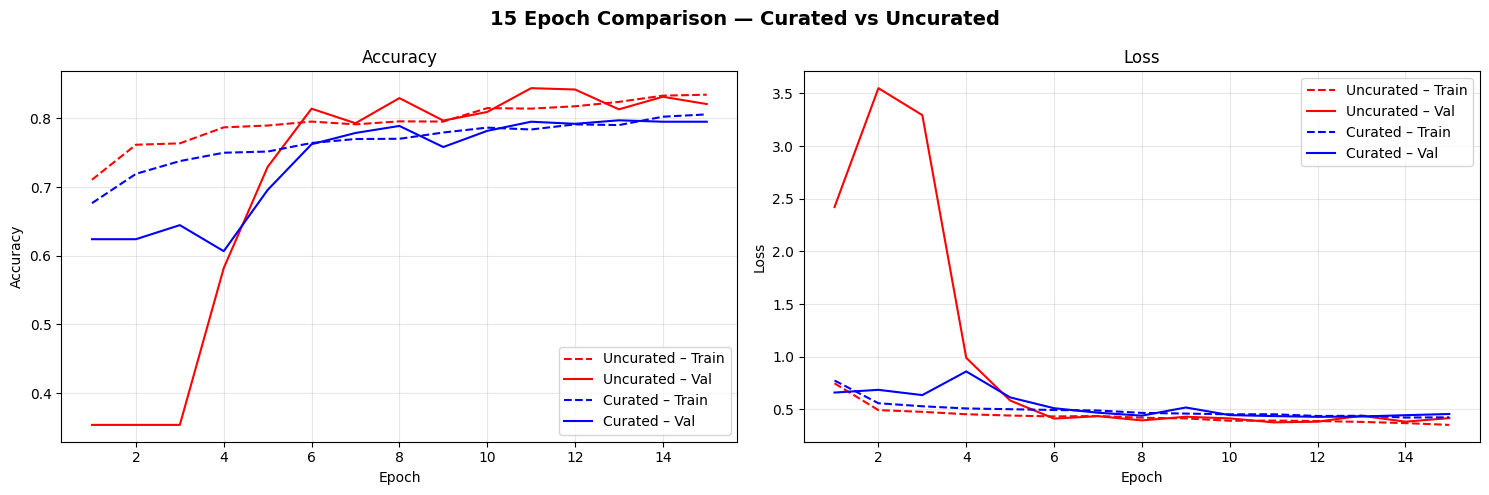

Plot saved!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json, matplotlib.pyplot as plt

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 15

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(128, 128, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ─── UNCURATED ────────────────────────────────────────────
print("=== Training on Uncurated Dataset ===")
train_gen_unc = train_datagen.flow_from_directory(
    "/content/dataset_uncurated/Training",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
val_gen_unc = val_datagen.flow_from_directory(
    "/content/dataset_uncurated/Validation",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
model_unc_15 = build_cnn()
history_unc_15 = model_unc_15.fit(
    train_gen_unc, validation_data=val_gen_unc, epochs=EPOCHS
)
model_unc_15.save("/content/drive/MyDrive/cnn_uncurated_15.keras")
with open("/content/drive/MyDrive/history_uncurated_15.json", "w") as f:
    json.dump(history_unc_15.history, f)
print("Uncurated 15 epoch model saved!")

# ─── CURATED ──────────────────────────────────────────────
print("\n=== Training on Curated Dataset ===")
train_gen_cur = train_datagen.flow_from_directory(
    "/content/dataset_curated/Training",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
val_gen_cur = val_datagen.flow_from_directory(
    "/content/dataset_curated/Validation",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
model_cur_15 = build_cnn()
history_cur_15 = model_cur_15.fit(
    train_gen_cur, validation_data=val_gen_cur, epochs=EPOCHS
)
model_cur_15.save("/content/drive/MyDrive/cnn_curated_15.keras")
with open("/content/drive/MyDrive/history_curated_15.json", "w") as f:
    json.dump(history_cur_15.history, f)
print("Curated 15 epoch model saved!")

# ─── PLOT ─────────────────────────────────────────────────
epochs = range(1, 16)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("15 Epoch Comparison — Curated vs Uncurated", fontsize=14, fontweight='bold')

axes[0].plot(epochs, history_unc_15.history['accuracy'],     'r--', label='Uncurated – Train')
axes[0].plot(epochs, history_unc_15.history['val_accuracy'], 'r-',  label='Uncurated – Val')
axes[0].plot(epochs, history_cur_15.history['accuracy'],     'b--', label='Curated – Train')
axes[0].plot(epochs, history_cur_15.history['val_accuracy'], 'b-',  label='Curated – Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history_unc_15.history['loss'],     'r--', label='Uncurated – Train')
axes[1].plot(epochs, history_unc_15.history['val_loss'], 'r-',  label='Uncurated – Val')
axes[1].plot(epochs, history_cur_15.history['loss'],     'b--', label='Curated – Train')
axes[1].plot(epochs, history_cur_15.history['val_loss'], 'b-',  label='Curated – Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/comparison_15epochs.png", dpi=150)
plt.show()
print("Plot saved!")

Found 533 images belonging to 2 classes.
Found 514 images belonging to 2 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step

Uncurated 15 Epochs
Accuracy:    78.61%
Sensitivity: 78.45%
Specificity: 78.92%
Precision:   87.50%
F1 Score:    0.8273

TN: 146  FP: 39  FN: 75  TP: 273


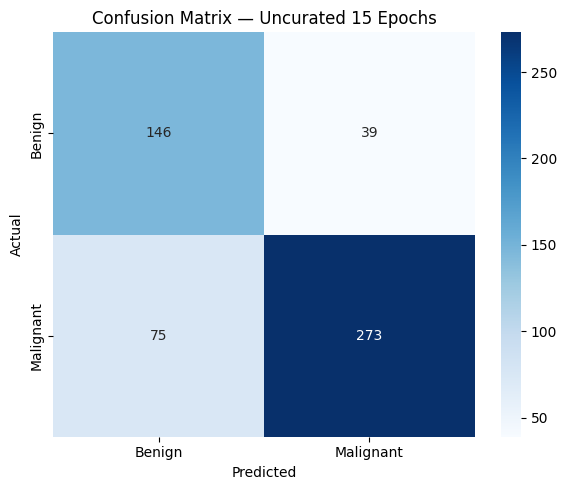

17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 598ms/step

Curated 15 Epochs
Accuracy:    77.24%
Sensitivity: 58.38%
Specificity: 87.84%
Precision:   72.97%
F1 Score:    0.6486

TN: 289  FP: 40  FN: 77  TP: 108


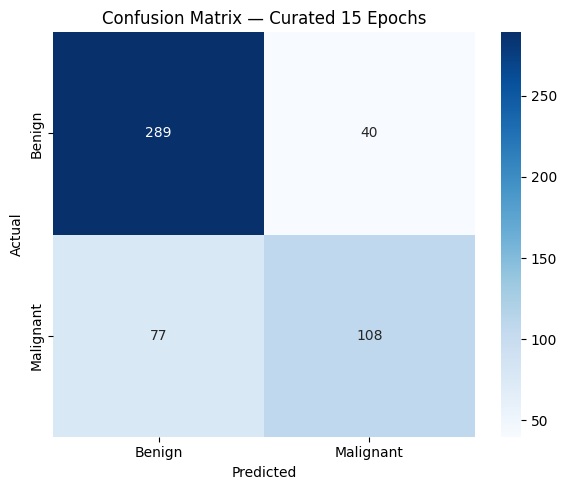


Metric                     Uncurated (15)         Curated (15)
Accuracy                           78.61%               77.24%
Sensitivity                        78.45%               58.38%
Specificity                        78.92%               87.84%
Precision                          87.50%               72.97%
F1 Score                           0.8273               0.6486
True Negatives                        146                  289
False Positives                        39                   40
False Negatives                        75                   77
True Positives                        273                  108


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ─── LOAD MODELS ──────────────────────────────────────────
model_unc_15 = load_model("/content/drive/MyDrive/cnn_uncurated_15.keras")
model_cur_15 = load_model("/content/drive/MyDrive/cnn_curated_15.keras")

# ─── TEST DATA ────────────────────────────────────────────
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen_unc = test_datagen.flow_from_directory(
    "/content/dataset_uncurated/Test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)
test_gen_cur = test_datagen.flow_from_directory(
    "/content/dataset_curated/Test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ─── EVALUATE FUNCTION ────────────────────────────────────
def evaluate_model(model, test_gen, label):
    loss, accuracy = model.evaluate(test_gen, verbose=0)
    predictions = (model.predict(test_gen) > 0.5).astype(int).flatten()
    true_labels  = test_gen.classes
    class_names  = list(test_gen.class_indices.keys())

    cm = confusion_matrix(true_labels, predictions)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision   = tp / (tp + fp)
    f1          = 2 * (precision * sensitivity) / (precision + sensitivity)

    print(f"\n{'='*40}")
    print(f"{label}")
    print(f"{'='*40}")
    print(f"Accuracy:    {accuracy*100:.2f}%")
    print(f"Sensitivity: {sensitivity*100:.2f}%")
    print(f"Specificity: {specificity*100:.2f}%")
    print(f"Precision:   {precision*100:.2f}%")
    print(f"F1 Score:    {f1:.4f}")
    print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Confusion Matrix — {label}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/cm_15epoch_{label.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

    return {
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

# ─── RUN BOTH ─────────────────────────────────────────────
results_unc = evaluate_model(model_unc_15, test_gen_unc, "Uncurated 15 Epochs")
results_cur = evaluate_model(model_cur_15, test_gen_cur, "Curated 15 Epochs")

# ─── SUMMARY TABLE ────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Metric':<20} {'Uncurated (15)':>20} {'Curated (15)':>20}")
print("="*70)
print(f"{'Accuracy':<20} {results_unc['accuracy']*100:>19.2f}% {results_cur['accuracy']*100:>19.2f}%")
print(f"{'Sensitivity':<20} {results_unc['sensitivity']*100:>19.2f}% {results_cur['sensitivity']*100:>19.2f}%")
print(f"{'Specificity':<20} {results_unc['specificity']*100:>19.2f}% {results_cur['specificity']*100:>19.2f}%")
print(f"{'Precision':<20} {results_unc['precision']*100:>19.2f}% {results_cur['precision']*100:>19.2f}%")
print(f"{'F1 Score':<20} {results_unc['f1']:>20.4f} {results_cur['f1']:>20.4f}")
print(f"{'True Negatives':<20} {results_unc['tn']:>20} {results_cur['tn']:>20}")
print(f"{'False Positives':<20} {results_unc['fp']:>20} {results_cur['fp']:>20}")
print(f"{'False Negatives':<20} {results_unc['fn']:>20} {results_cur['fn']:>20}")
print(f"{'True Positives':<20} {results_unc['tp']:>20} {results_cur['tp']:>20}")
print("="*70)

=== Training on Uncurated Dataset ===
Found 2965 images belonging to 2 classes.
Found 1038 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 51s 464ms/step - accuracy: 0.7032 - loss: 0.7146 - val_accuracy: 0.3536 - val_loss: 0.8065
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 423ms/step - accuracy: 0.7585 - loss: 0.4853 - val_accuracy: 0.3536 - val_loss: 1.4100
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 41s 445ms/step - accuracy: 0.7767 - loss: 0.4700 - val_accuracy: 0.4557 - val_loss: 0.8503
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 420ms/step - accuracy: 0.7868 - loss: 0.4419 - val_accuracy: 0.5896 - val_loss: 0.8883
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 419ms/step - accuracy: 0.7899 - loss: 0.4433 - val_accuracy: 0.7543 - val_loss: 0.4877
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 40s 430ms/step - accuracy: 0.7855 - loss: 0.4408 - val_accuracy: 0.8112 - val_loss: 0.4104
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 424ms/step - accuracy: 0.8003 - loss: 0.4157 - val_accuracy: 0.7919 - val_loss: 0.4575
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 37s 403ms/step - accuracy: 0.8007 - loss: 0.4152 - val_accu

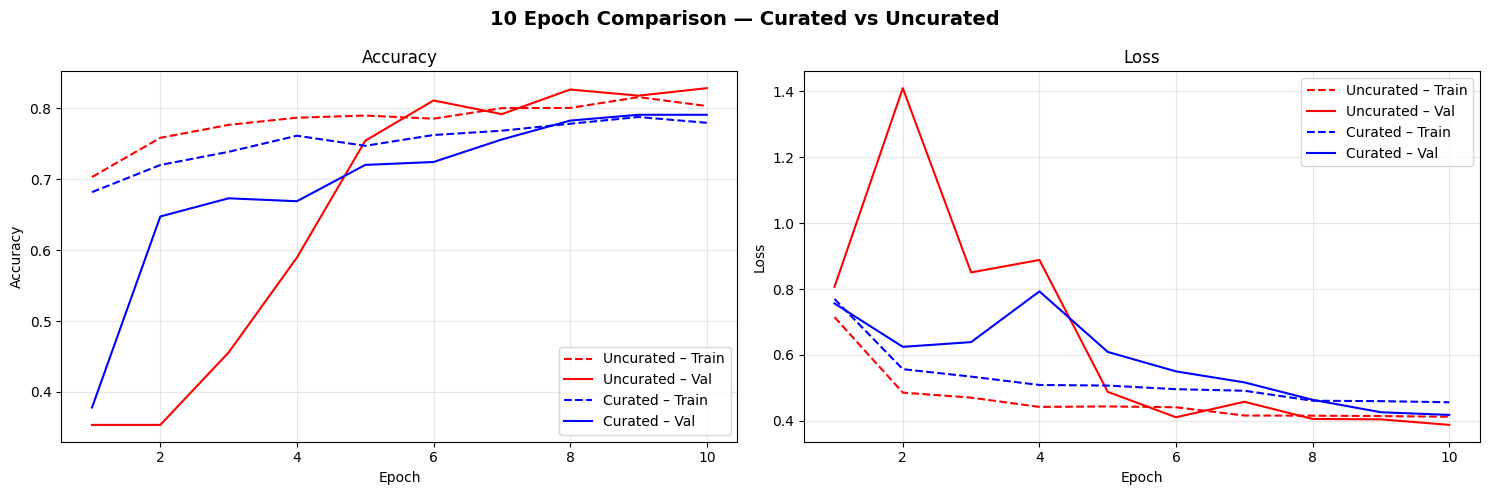

Plot saved!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json, matplotlib.pyplot as plt

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 10

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(128, 128, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ─── UNCURATED ────────────────────────────────────────────
print("=== Training on Uncurated Dataset ===")
train_gen_unc = train_datagen.flow_from_directory(
    "/content/dataset_uncurated/Training",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
val_gen_unc = val_datagen.flow_from_directory(
    "/content/dataset_uncurated/Validation",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
model_unc_10 = build_cnn()
history_unc_10 = model_unc_10.fit(
    train_gen_unc, validation_data=val_gen_unc, epochs=EPOCHS
)
model_unc_10.save("/content/drive/MyDrive/cnn_uncurated_10.keras")
with open("/content/drive/MyDrive/history_uncurated_10.json", "w") as f:
    json.dump(history_unc_10.history, f)
print("Uncurated 10 epoch model saved!")

# ─── CURATED ──────────────────────────────────────────────
print("\n=== Training on Curated Dataset ===")
train_gen_cur = train_datagen.flow_from_directory(
    "/content/dataset_curated/Training",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
val_gen_cur = val_datagen.flow_from_directory(
    "/content/dataset_curated/Validation",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
model_cur_10 = build_cnn()
history_cur_10 = model_cur_10.fit(
    train_gen_cur, validation_data=val_gen_cur, epochs=EPOCHS
)
model_cur_10.save("/content/drive/MyDrive/cnn_curated_10.keras")
with open("/content/drive/MyDrive/history_curated_10.json", "w") as f:
    json.dump(history_cur_10.history, f)
print("Curated 10 epoch model saved!")

# ─── PLOT ─────────────────────────────────────────────────
epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("10 Epoch Comparison — Curated vs Uncurated", fontsize=14, fontweight='bold')

axes[0].plot(epochs, history_unc_10.history['accuracy'],     'r--', label='Uncurated – Train')
axes[0].plot(epochs, history_unc_10.history['val_accuracy'], 'r-',  label='Uncurated – Val')
axes[0].plot(epochs, history_cur_10.history['accuracy'],     'b--', label='Curated – Train')
axes[0].plot(epochs, history_cur_10.history['val_accuracy'], 'b-',  label='Curated – Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history_unc_10.history['loss'],     'r--', label='Uncurated – Train')
axes[1].plot(epochs, history_unc_10.history['val_loss'], 'r-',  label='Uncurated – Val')
axes[1].plot(epochs, history_cur_10.history['loss'],     'b--', label='Curated – Train')
axes[1].plot(epochs, history_cur_10.history['val_loss'], 'b-',  label='Curated – Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/comparison_10epochs.png", dpi=150)
plt.show()
print("Plot saved!")

Found 533 images belonging to 2 classes.
Found 514 images belonging to 2 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step

Uncurated 10 Epochs
Accuracy:    81.61%
Sensitivity: 95.98%
Specificity: 54.59%
Precision:   79.90%
F1 Score:    0.8721

TN: 101  FP: 84  FN: 14  TP: 334


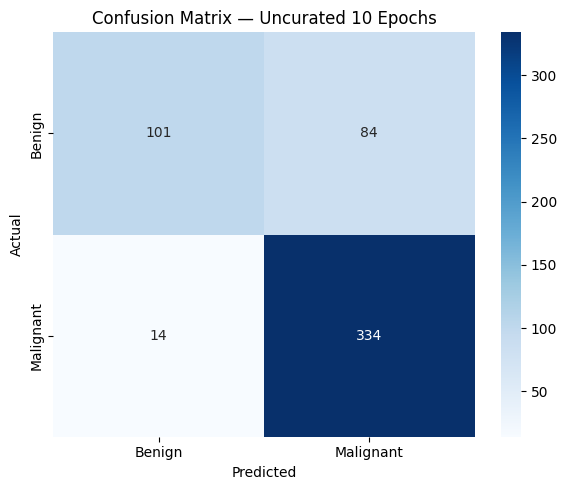

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 634ms/step

Curated 10 Epochs
Accuracy:    76.85%
Sensitivity: 69.73%
Specificity: 80.85%
Precision:   67.19%
F1 Score:    0.6844

TN: 266  FP: 63  FN: 56  TP: 129


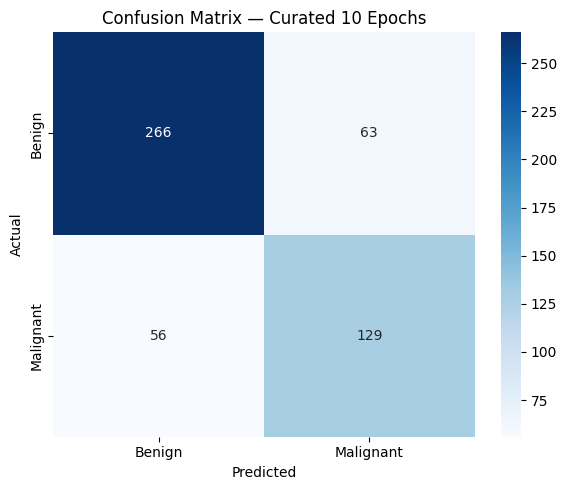


Metric                     Uncurated (10)         Curated (10)
Accuracy                           81.61%               76.85%
Sensitivity                        95.98%               69.73%
Specificity                        54.59%               80.85%
Precision                          79.90%               67.19%
F1 Score                           0.8721               0.6844
True Negatives                        101                  266
False Positives                        84                   63
False Negatives                        14                   56
True Positives                        334                  129


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ─── LOAD MODELS ──────────────────────────────────────────
model_unc_10 = load_model("/content/drive/MyDrive/cnn_uncurated_10.keras")
model_cur_10 = load_model("/content/drive/MyDrive/cnn_curated_10.keras")

# ─── TEST DATA ────────────────────────────────────────────
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen_unc = test_datagen.flow_from_directory(
    "/content/dataset_uncurated/Test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)
test_gen_cur = test_datagen.flow_from_directory(
    "/content/dataset_curated/Test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ─── EVALUATE FUNCTION ────────────────────────────────────
def evaluate_model(model, test_gen, label):
    loss, accuracy = model.evaluate(test_gen, verbose=0)
    predictions = (model.predict(test_gen) > 0.5).astype(int).flatten()
    true_labels  = test_gen.classes
    class_names  = list(test_gen.class_indices.keys())

    cm = confusion_matrix(true_labels, predictions)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision   = tp / (tp + fp)
    f1          = 2 * (precision * sensitivity) / (precision + sensitivity)

    print(f"\n{'='*40}")
    print(f"{label}")
    print(f"{'='*40}")
    print(f"Accuracy:    {accuracy*100:.2f}%")
    print(f"Sensitivity: {sensitivity*100:.2f}%")
    print(f"Specificity: {specificity*100:.2f}%")
    print(f"Precision:   {precision*100:.2f}%")
    print(f"F1 Score:    {f1:.4f}")
    print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Confusion Matrix — {label}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/cm_10epoch_{label.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

    return {
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

# ─── RUN BOTH ─────────────────────────────────────────────
results_unc = evaluate_model(model_unc_10, test_gen_unc, "Uncurated 10 Epochs")
results_cur = evaluate_model(model_cur_10, test_gen_cur, "Curated 10 Epochs")

# ─── SUMMARY TABLE ────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Metric':<20} {'Uncurated (10)':>20} {'Curated (10)':>20}")
print("="*70)
print(f"{'Accuracy':<20} {results_unc['accuracy']*100:>19.2f}% {results_cur['accuracy']*100:>19.2f}%")
print(f"{'Sensitivity':<20} {results_unc['sensitivity']*100:>19.2f}% {results_cur['sensitivity']*100:>19.2f}%")
print(f"{'Specificity':<20} {results_unc['specificity']*100:>19.2f}% {results_cur['specificity']*100:>19.2f}%")
print(f"{'Precision':<20} {results_unc['precision']*100:>19.2f}% {results_cur['precision']*100:>19.2f}%")
print(f"{'F1 Score':<20} {results_unc['f1']:>20.4f} {results_cur['f1']:>20.4f}")
print(f"{'True Negatives':<20} {results_unc['tn']:>20} {results_cur['tn']:>20}")
print(f"{'False Positives':<20} {results_unc['fp']:>20} {results_cur['fp']:>20}")
print(f"{'False Negatives':<20} {results_unc['fn']:>20} {results_cur['fn']:>20}")
print(f"{'True Positives':<20} {results_unc['tp']:>20} {results_cur['tp']:>20}")
print("="*70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 366 images belonging to 2 classes.
Found 368 images belonging to 2 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 110s 10s/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 150s 14s/step


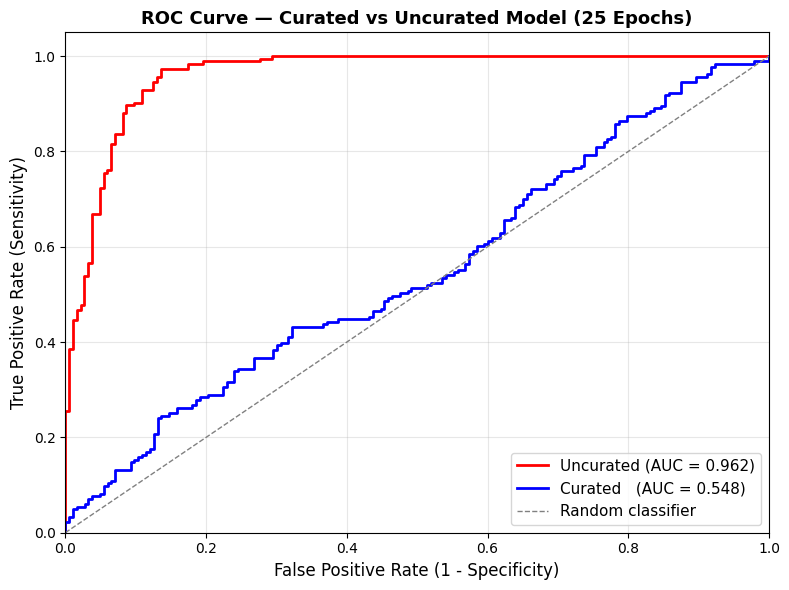

Curated   AUC: 0.548
Uncurated AUC: 0.962


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive

drive.mount('/content/drive')

# ── Config ─────────────────────────────────────────────────────────────
CURATED_MODEL_PATH   = '/content/drive/MyDrive/cnn_curated.keras'
UNCURATED_MODEL_PATH = '/content/drive/MyDrive/cnn_uncurated.keras'
CURATED_DIR          = '/content/drive/MyDrive/Curated set'
UNCURATED_DIR        = '/content/drive/MyDrive/Uncurated set'

IMG_SIZE = (128, 128)
BATCH    = 32

# ── Data generators (no augmentation, shuffle off for consistent labels)
def make_test_generator(data_dir):
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.1)
    test_gen = datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode='binary',
        subset='validation',
        shuffle=False
    )
    return test_gen

curated_test   = make_test_generator(CURATED_DIR)
uncurated_test = make_test_generator(UNCURATED_DIR)

# ── Load models ─────────────────────────────────────────────────────────
curated_model   = load_model(CURATED_MODEL_PATH)
uncurated_model = load_model(UNCURATED_MODEL_PATH)

# ── Get predictions ─────────────────────────────────────────────────────
curated_probs   = curated_model.predict(curated_test).ravel()
uncurated_probs = uncurated_model.predict(uncurated_test).ravel()

curated_labels   = curated_test.classes
uncurated_labels = uncurated_test.classes

# ── Compute ROC curves ──────────────────────────────────────────────────
fpr_c, tpr_c, _ = roc_curve(curated_labels,   curated_probs)
fpr_u, tpr_u, _ = roc_curve(uncurated_labels, uncurated_probs)

auc_c = auc(fpr_c, tpr_c)
auc_u = auc(fpr_u, tpr_u)

# ── Plot ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

plt.plot(fpr_u, tpr_u, color='red',  lw=2, label=f'Uncurated (AUC = {auc_u:.3f})')
plt.plot(fpr_c, tpr_c, color='blue', lw=2, label=f'Curated   (AUC = {auc_c:.3f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)',       fontsize=12)
plt.title('ROC Curve — Curated vs Uncurated Model (25 Epochs)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_25_epochs.png', dpi=300)
plt.show()

print(f'Curated   AUC: {auc_c:.3f}')
print(f'Uncurated AUC: {auc_u:.3f}')

# ── Download ────────────────────────────────────────────────────────────
from google.colab import files
files.download('roc_curve_25_epochs.png')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 366 images belonging to 2 classes.
Found 368 images belonging to 2 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step

Generating Precision-Recall Curve...


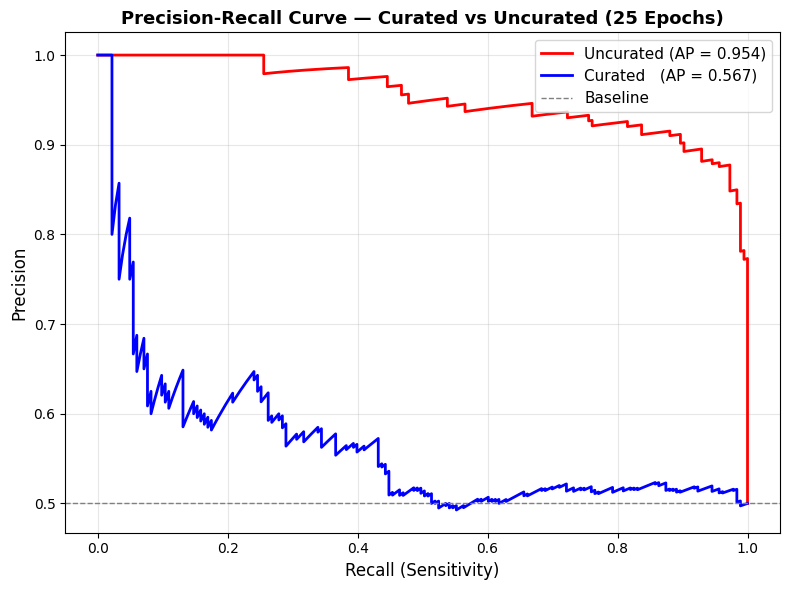

Uncurated AP: 0.954
Curated   AP: 0.567

Generating Threshold Analysis...


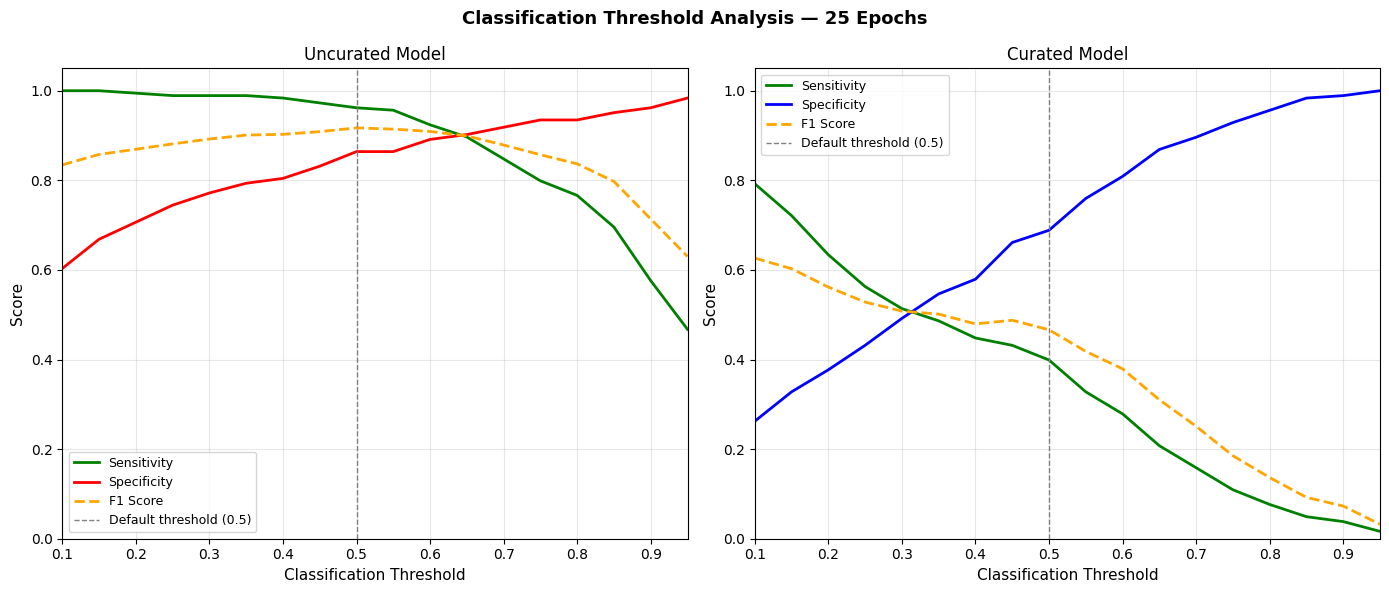


Uncurated — thresholds where sensitivity >= 0.90:
  Threshold: 0.10 | Sensitivity: 1.000 | Specificity: 0.603
  Threshold: 0.15 | Sensitivity: 1.000 | Specificity: 0.668
  Threshold: 0.20 | Sensitivity: 0.995 | Specificity: 0.707
  Threshold: 0.25 | Sensitivity: 0.989 | Specificity: 0.745
  Threshold: 0.30 | Sensitivity: 0.989 | Specificity: 0.772
  Threshold: 0.35 | Sensitivity: 0.989 | Specificity: 0.793
  Threshold: 0.40 | Sensitivity: 0.984 | Specificity: 0.804
  Threshold: 0.45 | Sensitivity: 0.973 | Specificity: 0.832
  Threshold: 0.50 | Sensitivity: 0.962 | Specificity: 0.864
  Threshold: 0.55 | Sensitivity: 0.957 | Specificity: 0.864
  Threshold: 0.60 | Sensitivity: 0.924 | Specificity: 0.891

Curated — thresholds where sensitivity >= 0.90:
Using layer: conv2d_3
Using layer: conv2d_3
Using layer: conv2d_7
Using layer: conv2d_7


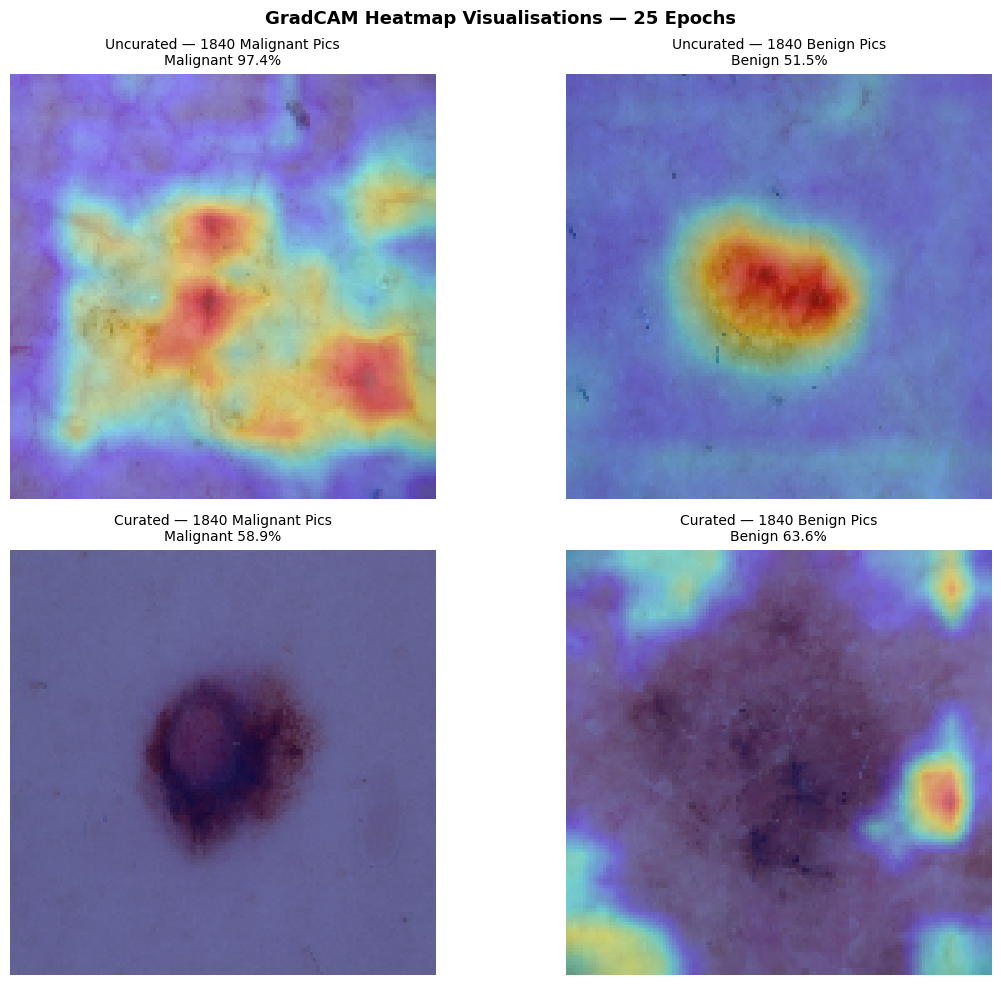

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All tests complete. Three files downloaded.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import precision_recall_curve, average_precision_score
from google.colab import drive, files
import os

drive.mount('/content/drive')

# ── Config ─────────────────────────────────────────────────────────────
CURATED_MODEL_PATH   = '/content/drive/MyDrive/cnn_curated.keras'
UNCURATED_MODEL_PATH = '/content/drive/MyDrive/cnn_uncurated.keras'
CURATED_DIR          = '/content/drive/MyDrive/Curated set'
UNCURATED_DIR        = '/content/drive/MyDrive/Uncurated set'

IMG_SIZE = (128, 128)
BATCH    = 32

# ── Data generators ─────────────────────────────────────────────────────
def make_test_generator(data_dir):
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.1)
    test_gen = datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode='binary',
        subset='validation',
        shuffle=False
    )
    return test_gen

curated_test   = make_test_generator(CURATED_DIR)
uncurated_test = make_test_generator(UNCURATED_DIR)

# ── Load models ─────────────────────────────────────────────────────────
curated_model   = load_model(CURATED_MODEL_PATH)
uncurated_model = load_model(UNCURATED_MODEL_PATH)

# ── Get predictions ─────────────────────────────────────────────────────
curated_probs   = curated_model.predict(curated_test).ravel()
uncurated_probs = uncurated_model.predict(uncurated_test).ravel()
curated_labels   = curated_test.classes
uncurated_labels = uncurated_test.classes

# ════════════════════════════════════════════════════════════════════════
# TEST 1 — PRECISION-RECALL CURVE
# ════════════════════════════════════════════════════════════════════════
print('\nGenerating Precision-Recall Curve...')

prec_c, rec_c, _ = precision_recall_curve(curated_labels,   curated_probs)
prec_u, rec_u, _ = precision_recall_curve(uncurated_labels, uncurated_probs)

ap_c = average_precision_score(curated_labels,   curated_probs)
ap_u = average_precision_score(uncurated_labels, uncurated_probs)

plt.figure(figsize=(8, 6))
plt.plot(rec_u, prec_u, color='red',  lw=2, label=f'Uncurated (AP = {ap_u:.3f})')
plt.plot(rec_c, prec_c, color='blue', lw=2, label=f'Curated   (AP = {ap_c:.3f})')
plt.axhline(y=0.5, color='grey', linestyle='--', lw=1, label='Baseline')
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — Curated vs Uncurated (25 Epochs)', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300)
plt.show()
print(f'Uncurated AP: {ap_u:.3f}')
print(f'Curated   AP: {ap_c:.3f}')


# ════════════════════════════════════════════════════════════════════════
# TEST 2 — CLASSIFICATION THRESHOLD ANALYSIS
# ════════════════════════════════════════════════════════════════════════
print('\nGenerating Threshold Analysis...')

thresholds = np.arange(0.1, 1.0, 0.05)

def compute_threshold_metrics(probs, labels, thresholds):
    sensitivities, specificities, f1s = [], [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tp = np.sum((preds == 1) & (labels == 1))
        tn = np.sum((preds == 0) & (labels == 0))
        fp = np.sum((preds == 1) & (labels == 0))
        fn = np.sum((preds == 0) & (labels == 1))
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1   = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0
        sensitivities.append(sens)
        specificities.append(spec)
        f1s.append(f1)
    return sensitivities, specificities, f1s

sens_u, spec_u, f1_u = compute_threshold_metrics(uncurated_probs, uncurated_labels, thresholds)
sens_c, spec_c, f1_c = compute_threshold_metrics(curated_probs,   curated_labels,   thresholds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Classification Threshold Analysis — 25 Epochs', fontsize=13, fontweight='bold')

for ax, sens, spec, f1, title, colour in [
    (axes[0], sens_u, spec_u, f1_u, 'Uncurated', 'red'),
    (axes[1], sens_c, spec_c, f1_c, 'Curated',   'blue'),
]:
    ax.plot(thresholds, sens, color='green',  lw=2, label='Sensitivity')
    ax.plot(thresholds, spec, color=colour,   lw=2, label='Specificity')
    ax.plot(thresholds, f1,   color='orange', lw=2, label='F1 Score', linestyle='--')
    ax.axvline(x=0.5, color='grey', linestyle='--', lw=1, label='Default threshold (0.5)')
    ax.set_xlabel('Classification Threshold', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{title} Model', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.1, 0.95])
    ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=300)
plt.show()

# Print optimal threshold for sensitivity >= 0.90
print('\nUncurated — thresholds where sensitivity >= 0.90:')
for t, s, sp in zip(thresholds, sens_u, spec_u):
    if s >= 0.90:
        print(f'  Threshold: {t:.2f} | Sensitivity: {s:.3f} | Specificity: {sp:.3f}')

print('\nCurated — thresholds where sensitivity >= 0.90:')
for t, s, sp in zip(thresholds, sens_c, spec_c):
    if s >= 0.90:
        print(f'  Threshold: {t:.2f} | Sensitivity: {s:.3f} | Specificity: {sp:.3f}')


# ════════════════════════════════════════════════════════════════════════
# TEST 3 — GRAD-CAM VISUALISATION
# ════════════════════════════════════════════════════════════════════════
def make_gradcam_heatmap(img_array, model):
    # Force initialise the model
    _ = model.predict(img_array, verbose=0)

    # Find last conv layer
    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer_name = layer.name
            break
    print(f'Using layer: {last_conv_layer_name}')

    # Build functional grad model
    inputs = tf.keras.Input(shape=(128, 128, 3))
    x = inputs
    conv_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x

    grad_model = tf.keras.Model(inputs=inputs, outputs=[conv_output, x])

    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        loss = predictions[:, 0]

    grads    = tape.gradient(loss, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_path, model, title, ax):
    img      = load_img(img_path, target_size=IMG_SIZE)
    img_arr  = img_to_array(img) / 255.0
    inp      = np.expand_dims(img_arr, axis=0)
    heatmap  = make_gradcam_heatmap(inp, model)
    heatmap  = np.uint8(255 * heatmap)
    heatmap  = np.array(tf.image.resize([heatmap[..., np.newaxis]], IMG_SIZE)[0, :, :, 0])
    colored  = cm.jet(heatmap / 255.0)[:, :, :3]
    overlay  = 0.6 * img_arr + 0.4 * colored
    overlay  = np.clip(overlay, 0, 1)
    pred     = model.predict(inp, verbose=0)[0][0]
    label    = f'Malignant {pred*100:.1f}%' if pred >= 0.5 else f'Benign {(1-pred)*100:.1f}%'
    ax.imshow(overlay)
    ax.set_title(f'{title}\n{label}', fontsize=10)
    ax.axis('off')

# Get sample images — one benign, one malignant
def get_sample_images(data_dir, n=2):
    samples = []
    for class_folder in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_folder)
        if os.path.isdir(class_path):
            images = os.listdir(class_path)
            if images:
                samples.append(os.path.join(class_path, images[0]))
        if len(samples) >= n:
            break
    return samples

uncurated_samples = get_sample_images(UNCURATED_DIR)
curated_samples   = get_sample_images(CURATED_DIR)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('GradCAM Heatmap Visualisations — 25 Epochs', fontsize=13, fontweight='bold')

for i, img_path in enumerate(uncurated_samples[:2]):
    overlay_gradcam(img_path, uncurated_model, f'Uncurated — {os.path.basename(os.path.dirname(img_path))}', axes[0, i])

for i, img_path in enumerate(curated_samples[:2]):
    overlay_gradcam(img_path, curated_model, f'Curated — {os.path.basename(os.path.dirname(img_path))}', axes[1, i])

plt.tight_layout()
plt.savefig('gradcam_visualisations.png', dpi=300)
plt.show()

# ── Download all outputs ────────────────────────────────────────────────
files.download('precision_recall_curve.png')
files.download('threshold_analysis.png')
files.download('gradcam_visualisations.png')

print('\nAll tests complete. Three files downloaded.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


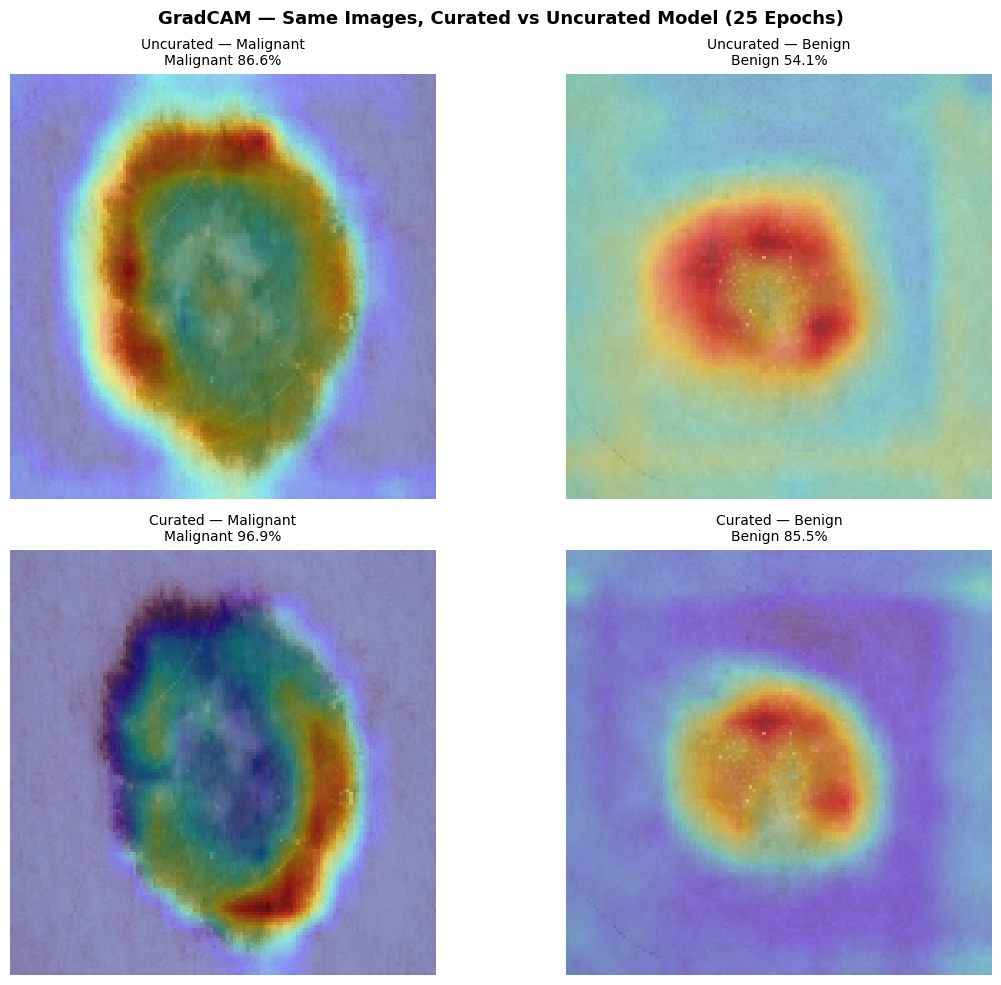

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from google.colab import drive, files
import os

drive.mount('/content/drive')

# ── Config ─────────────────────────────────────────────────────────────
CURATED_MODEL_PATH   = '/content/drive/MyDrive/cnn_curated.keras'
UNCURATED_MODEL_PATH = '/content/drive/MyDrive/cnn_uncurated.keras'

# ── Pick specific images manually — same for both models ────────────────
# Replace these with actual paths to one benign and one malignant image
BENIGN_IMAGE_PATH    = '/content/drive/MyDrive/B Test.jpg'
MALIGNANT_IMAGE_PATH = '/content/drive/MyDrive/M Test.jpg'

IMG_SIZE = (128, 128)

# ── Load models ─────────────────────────────────────────────────────────
curated_model   = load_model(CURATED_MODEL_PATH)
uncurated_model = load_model(UNCURATED_MODEL_PATH)

# ── GradCAM function ────────────────────────────────────────────────────
def make_gradcam_heatmap(img_array, model):
    _ = model.predict(img_array, verbose=0)

    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer_name = layer.name
            break

    inputs = tf.keras.Input(shape=(128, 128, 3))
    x = inputs
    conv_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x

    grad_model = tf.keras.Model(inputs=inputs, outputs=[conv_output, x])

    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        loss = predictions[:, 0]

    grads    = tape.gradient(loss, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_path, model, title, ax):
    img     = load_img(img_path, target_size=IMG_SIZE)
    img_arr = img_to_array(img) / 255.0
    inp     = np.expand_dims(img_arr, axis=0)
    heatmap = make_gradcam_heatmap(inp, model)
    heatmap = np.uint8(255 * heatmap)
    heatmap = np.array(tf.image.resize(
        [heatmap[..., np.newaxis]], IMG_SIZE)[0, :, :, 0])
    colored = cm.jet(heatmap / 255.0)[:, :, :3]
    overlay = np.clip(0.6 * img_arr + 0.4 * colored, 0, 1)
    pred    = model.predict(inp, verbose=0)[0][0]
    label   = f'Malignant {pred*100:.1f}%' if pred >= 0.5 else f'Benign {(1-pred)*100:.1f}%'
    ax.imshow(overlay)
    ax.set_title(f'{title}\n{label}', fontsize=10)
    ax.axis('off')

# ── Plot — 2x2 grid, same images, both models ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('GradCAM — Same Images, Curated vs Uncurated Model (25 Epochs)',
             fontsize=13, fontweight='bold')

# Row labels
axes[0, 0].set_ylabel('Uncurated', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Curated',   fontsize=12, fontweight='bold')

overlay_gradcam(MALIGNANT_IMAGE_PATH, uncurated_model, 'Uncurated — Malignant', axes[0, 0])
overlay_gradcam(BENIGN_IMAGE_PATH,    uncurated_model, 'Uncurated — Benign',    axes[0, 1])
overlay_gradcam(MALIGNANT_IMAGE_PATH, curated_model,   'Curated — Malignant',   axes[1, 0])
overlay_gradcam(BENIGN_IMAGE_PATH,    curated_model,   'Curated — Benign',      axes[1, 1])

plt.tight_layout()
plt.savefig('gradcam_same_images.png', dpi=300)
plt.show()

files.download('gradcam_same_images.png')
print('Done.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 367 images belonging to 2 classes.
Found 368 images belonging to 2 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step
Uncurated Model:
  Malignant scores — Mean: 0.871 | Std: 0.157
  Benign scores    — Mean: 0.181 | Std: 0.268
  Separation       — 0.690

Curated Model:
  Malignant scores — Mean: 0.381 | Std: 0.281
  Benign scores    — Mean: 0.341 | Std: 0.262
  Separation       — 0.040


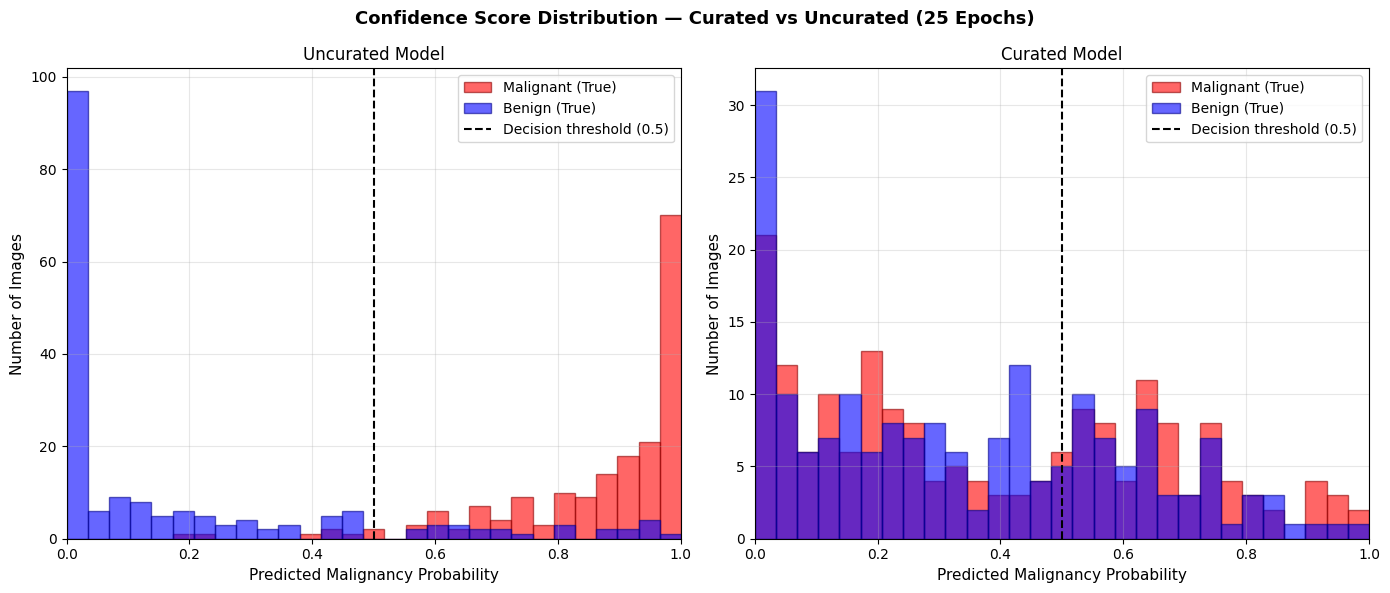

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive, files

drive.mount('/content/drive')

# ── Config ─────────────────────────────────────────────────────────────
CURATED_MODEL_PATH   = '/content/drive/MyDrive/cnn_curated.keras'
UNCURATED_MODEL_PATH = '/content/drive/MyDrive/cnn_uncurated.keras'
CURATED_DIR          = '/content/drive/MyDrive/Curated set'
UNCURATED_DIR        = '/content/drive/MyDrive/Uncurated set'

IMG_SIZE = (128, 128)
BATCH    = 32

# ── Data generators ─────────────────────────────────────────────────────
def make_test_generator(data_dir):
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.1)
    test_gen = datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode='binary',
        subset='validation',
        shuffle=False
    )
    return test_gen

curated_test   = make_test_generator(CURATED_DIR)
uncurated_test = make_test_generator(UNCURATED_DIR)

# ── Load models and get predictions ─────────────────────────────────────
curated_model   = load_model('/content/drive/MyDrive/cnn_curated.keras')
uncurated_model = load_model('/content/drive/MyDrive/cnn_uncurated.keras')

curated_probs   = curated_model.predict(curated_test).ravel()
uncurated_probs = uncurated_model.predict(uncurated_test).ravel()
curated_labels   = curated_test.classes
uncurated_labels = uncurated_test.classes

# ── Split probabilities by true class ───────────────────────────────────
unc_malignant = uncurated_probs[uncurated_labels == 1]
unc_benign    = uncurated_probs[uncurated_labels == 0]
cur_malignant = curated_probs[curated_labels == 1]
cur_benign    = curated_probs[curated_labels == 0]

# ── Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confidence Score Distribution — Curated vs Uncurated (25 Epochs)',
             fontsize=13, fontweight='bold')

bins = np.linspace(0, 1, 30)

for ax, mal, ben, title in [
    (axes[0], unc_malignant, unc_benign, 'Uncurated Model'),
    (axes[1], cur_malignant, cur_benign, 'Curated Model'),
]:
    ax.hist(mal, bins=bins, alpha=0.6, color='red',  label='Malignant (True)', edgecolor='darkred')
    ax.hist(ben, bins=bins, alpha=0.6, color='blue', label='Benign (True)',    edgecolor='darkblue')
    ax.axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Decision threshold (0.5)')
    ax.set_xlabel('Predicted Malignancy Probability', fontsize=11)
    ax.set_ylabel('Number of Images', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])

# ── Print summary stats ──────────────────────────────────────────────────
print('Uncurated Model:')
print(f'  Malignant scores — Mean: {unc_malignant.mean():.3f} | Std: {unc_malignant.std():.3f}')
print(f'  Benign scores    — Mean: {unc_benign.mean():.3f} | Std: {unc_benign.std():.3f}')
print(f'  Separation       — {unc_malignant.mean() - unc_benign.mean():.3f}')

print('\nCurated Model:')
print(f'  Malignant scores — Mean: {cur_malignant.mean():.3f} | Std: {cur_malignant.std():.3f}')
print(f'  Benign scores    — Mean: {cur_benign.mean():.3f} | Std: {cur_benign.std():.3f}')
print(f'  Separation       — {cur_malignant.mean() - cur_benign.mean():.3f}')

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=300)
plt.show()

files.download('confidence_distribution.png')
print('\nDone.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading model...
Model loaded.

Processing FST I...
  Found 1956 images in /content/drive/MyDrive/Skin type test/Benign/1
  Found 244 images in /content/drive/MyDrive/Skin type test/Malignant/1
  Sensitivity: 55.7% | Specificity: 80.8% | Accuracy: 78.0% | N=2200

Processing FST II...
  Found 2721 images in /content/drive/MyDrive/Skin type test/Benign/2
  Found 1445 images in /content/drive/MyDrive/Skin type test/Malignant/2
  Sensitivity: 61.2% | Specificity: 67.4% | Accuracy: 65.3% | N=4166

Processing FST III...
  Found 0 images in /content/drive/MyDrive/Skin type test/Benign/3
  Found 357 images in /content/drive/MyDrive/Skin type test/Malignant/3
  Sensitivity: 46.5% | Specificity: 0.0% | Accuracy: 46.5% | N=357

Processing FST IV...
  Found 0 images in /content/drive/MyDrive/Skin type test/Benign/4
  Found 32 images in /content/drive/MyDrive/Skin type te

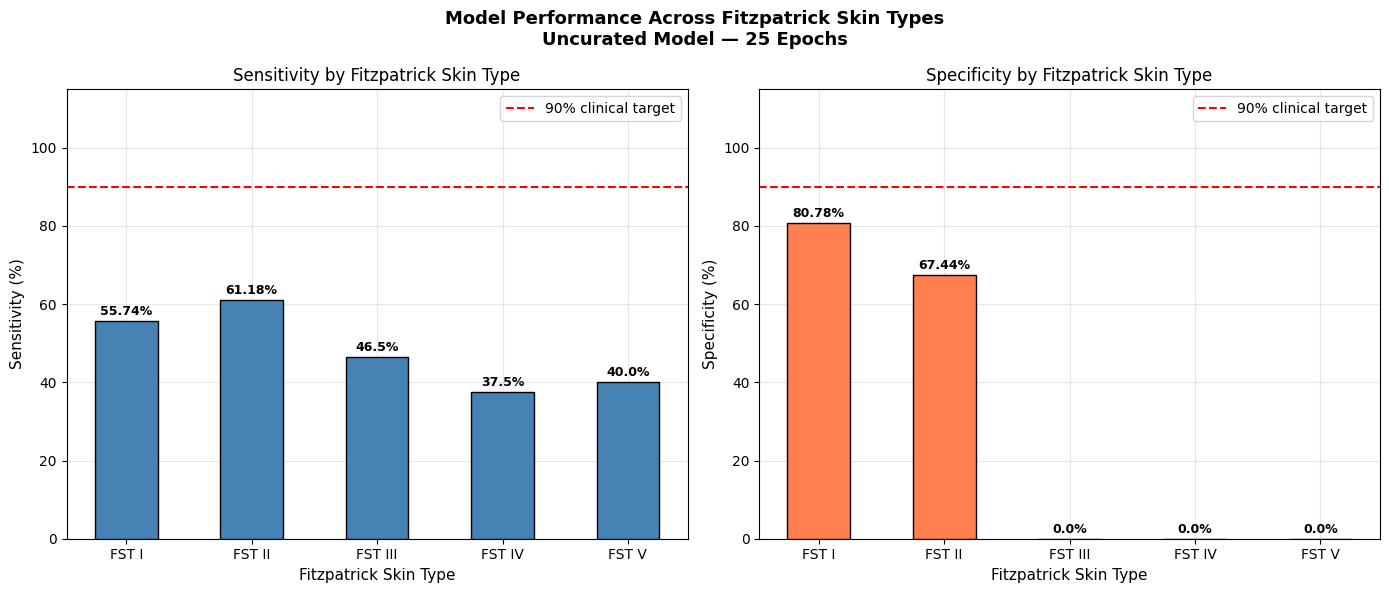

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done — fst_results.csv and fst_performance.png downloaded.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from google.colab import drive, files
import os

drive.mount('/content/drive')

# ── Config ─────────────────────────────────────────────────────────────
UNCURATED_MODEL_PATH = '/content/drive/MyDrive/cnn_uncurated.keras'
DATASET_DIR          = '/content/drive/MyDrive/Skin type test'
IMG_SIZE             = (128, 128)
FST_TYPES            = ['1', '2', '3', '4', '5']
FST_LABELS           = ['FST I', 'FST II', 'FST III', 'FST IV', 'FST V']

# ── Load model ──────────────────────────────────────────────────────────
print('Loading model...')
model = load_model(UNCURATED_MODEL_PATH)
print('Model loaded.')

# ── Helper — predict all images in a folder ─────────────────────────────
def predict_folder(folder_path, label):
    probs, labels = [], []
    if not os.path.exists(folder_path):
        print(f'  WARNING: folder not found — {folder_path}')
        return np.array([]), np.array([])
    image_files = [f for f in os.listdir(folder_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    print(f'  Found {len(image_files)} images in {folder_path}')
    for img_file in image_files:
        try:
            img  = load_img(os.path.join(folder_path, img_file), target_size=IMG_SIZE)
            arr  = img_to_array(img) / 255.0
            inp  = np.expand_dims(arr, axis=0)
            prob = model.predict(inp, verbose=0)[0][0]
            probs.append(prob)
            labels.append(label)
        except Exception as e:
            print(f'  Skipping {img_file}: {e}')
            continue
    return np.array(probs), np.array(labels)

# ── Run per FST group ───────────────────────────────────────────────────
results = []

for fst, fst_label in zip(FST_TYPES, FST_LABELS):
    print(f'\nProcessing {fst_label}...')

    benign_dir    = os.path.join(DATASET_DIR, 'Benign',    fst)
    malignant_dir = os.path.join(DATASET_DIR, 'Malignant', fst)

    ben_probs,  ben_labels  = predict_folder(benign_dir,    0)
    mal_probs,  mal_labels  = predict_folder(malignant_dir, 1)

    if len(ben_labels) == 0 and len(mal_labels) == 0:
        print(f'  Skipping {fst_label} — no images found')
        continue

    probs  = np.concatenate([ben_probs,  mal_probs])
    labels = np.concatenate([ben_labels, mal_labels])
    preds  = (probs >= 0.5).astype(int)

    tp = np.sum((preds == 1) & (labels == 1))
    tn = np.sum((preds == 0) & (labels == 0))
    fp = np.sum((preds == 1) & (labels == 0))
    fn = np.sum((preds == 0) & (labels == 1))

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy    = (tp + tn) / len(labels) if len(labels) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1          = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

    results.append({
        'FST':         fst_label,
        'N Benign':    len(ben_labels),
        'N Malignant': len(mal_labels),
        'Total':       len(labels),
        'Sensitivity': round(sensitivity * 100, 2),
        'Specificity': round(specificity * 100, 2),
        'Accuracy':    round(accuracy    * 100, 2),
        'Precision':   round(precision   * 100, 2),
        'F1 Score':    round(f1, 4),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)
    })

    print(f'  Sensitivity: {sensitivity*100:.1f}% | '
          f'Specificity: {specificity*100:.1f}% | '
          f'Accuracy: {accuracy*100:.1f}% | '
          f'N={len(labels)}')

# ── Results table ───────────────────────────────────────────────────────
df = pd.DataFrame(results)
print('\n════ RESULTS ════')
print(df.to_string(index=False))
df.to_csv('fst_results.csv', index=False)

# ── Plot ────────────────────────────────────────────────────────────────
x = np.arange(len(df))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Performance Across Fitzpatrick Skin Types\nUncurated Model — 25 Epochs',
             fontsize=13, fontweight='bold')

# Sensitivity
axes[0].bar(x, df['Sensitivity'], width=0.5, color='steelblue',
            edgecolor='black', zorder=3)
axes[0].axhline(y=90, color='red', linestyle='--', lw=1.5,
                label='90% clinical target')
for i, v in enumerate(df['Sensitivity']):
    axes[0].text(i, v + 1.5, f'{v}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Fitzpatrick Skin Type', fontsize=11)
axes[0].set_ylabel('Sensitivity (%)', fontsize=11)
axes[0].set_title('Sensitivity by Fitzpatrick Skin Type', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df['FST'])
axes[0].set_ylim([0, 115])
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, zorder=0)

# Specificity
axes[1].bar(x, df['Specificity'], width=0.5, color='coral',
            edgecolor='black', zorder=3)
axes[1].axhline(y=90, color='red', linestyle='--', lw=1.5,
                label='90% clinical target')
for i, v in enumerate(df['Specificity']):
    axes[1].text(i, v + 1.5, f'{v}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Fitzpatrick Skin Type', fontsize=11)
axes[1].set_ylabel('Specificity (%)', fontsize=11)
axes[1].set_title('Specificity by Fitzpatrick Skin Type', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df['FST'])
axes[1].set_ylim([0, 115])
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('fst_performance.png', dpi=300)
plt.show()

# ── Download ────────────────────────────────────────────────────────────
files.download('fst_results.csv')
files.download('fst_performance.png')
print('\nDone — fst_results.csv and fst_performance.png downloaded.')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path     = '/content/drive/MyDrive/Skin_type_test.zip'
extract_path = '/content/Skin_type_test'

print('Unzipping...')
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)
print('Done')

# Verify structure
for folder in ['Benign', 'Malignant']:
    for fst in ['1', '2', '3', '4', '5']:
        path = os.path.join(extract_path, folder, fst)
        count = len(os.listdir(path)) if os.path.exists(path) else 'NOT FOUND'
        print(f'{folder}/{fst}: {count} images')

Mounted at /content/drive
Unzipping...
Done
Benign/1: NOT FOUND images
Benign/2: NOT FOUND images
Benign/3: NOT FOUND images
Benign/4: NOT FOUND images
Benign/5: NOT FOUND images
Malignant/1: NOT FOUND images
Malignant/2: NOT FOUND images
Malignant/3: NOT FOUND images
Malignant/4: NOT FOUND images
Malignant/5: NOT FOUND images


In [ ]:
import os

extract_path = '/content/Skin_type_test'

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for d in dirs:
            print(f'{indent}  {d}/')


Skin_type_test/
  Skin type test/
  Skin type test/
    Benign/
    Malignant/
    Benign/
      6/
      3/
      1/
      5/
      4/
      2/
      6/
      3/
      1/
      5/
      4/
      2/
    Malignant/
      6/
      3/
      1/
      5/
      4/
      2/
      6/
      3/
      1/
      5/
      4/
      2/


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from google.colab import drive, files
import os

drive.mount('/content/drive')

# ── Config ─────────────────────────────────────────────────────────────
UNCURATED_MODEL_PATH = '/content/drive/MyDrive/cnn_uncurated.keras'
DATASET_DIR          = '/content/Skin_type_test'
IMG_SIZE             = (128, 128)
FST_TYPES            = ['1', '2', '3', '4', '5']
FST_LABELS           = ['FST I', 'FST II', 'FST III', 'FST IV', 'FST V']

# ── Load model ──────────────────────────────────────────────────────────
print('Loading model...')
model = load_model(UNCURATED_MODEL_PATH)
print('Model loaded.')

# ── Helper — predict all images in a folder ─────────────────────────────
def predict_folder(folder_path, label):
    probs, labels = [], []
    if not os.path.exists(folder_path):
        print(f'  WARNING: folder not found — {folder_path}')
        return np.array([]), np.array([])
    image_files = [f for f in os.listdir(folder_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    print(f'  Found {len(image_files)} images in {folder_path}')
    for img_file in image_files:
        try:
            img  = load_img(os.path.join(folder_path, img_file), target_size=IMG_SIZE)
            arr  = img_to_array(img) / 255.0
            inp  = np.expand_dims(arr, axis=0)
            prob = model.predict(inp, verbose=0)[0][0]
            probs.append(prob)
            labels.append(label)
        except Exception as e:
            print(f'  Skipping {img_file}: {e}')
            continue
    return np.array(probs), np.array(labels)

# ── Run per FST group ───────────────────────────────────────────────────
results = []

for fst, fst_label in zip(FST_TYPES, FST_LABELS):
    print(f'\nProcessing {fst_label}...')

    benign_dir    = os.path.join(DATASET_DIR, 'Benign',    fst)
    malignant_dir = os.path.join(DATASET_DIR, 'Malignant', fst)

    ben_probs,  ben_labels  = predict_folder(benign_dir,    0)
    mal_probs,  mal_labels  = predict_folder(malignant_dir, 1)

    if len(ben_labels) == 0 and len(mal_labels) == 0:
        print(f'  Skipping {fst_label} — no images found')
        continue

    probs  = np.concatenate([ben_probs,  mal_probs])
    labels = np.concatenate([ben_labels, mal_labels])
    preds  = (probs >= 0.5).astype(int)

    tp = np.sum((preds == 1) & (labels == 1))
    tn = np.sum((preds == 0) & (labels == 0))
    fp = np.sum((preds == 1) & (labels == 0))
    fn = np.sum((preds == 0) & (labels == 1))

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy    = (tp + tn) / len(labels) if len(labels) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1          = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

    results.append({
        'FST':         fst_label,
        'N Benign':    len(ben_labels),
        'N Malignant': len(mal_labels),
        'Total':       len(labels),
        'Sensitivity': round(sensitivity * 100, 2),
        'Specificity': round(specificity * 100, 2),
        'Accuracy':    round(accuracy    * 100, 2),
        'Precision':   round(precision   * 100, 2),
        'F1 Score':    round(f1, 4),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)
    })

    print(f'  Sensitivity: {sensitivity*100:.1f}% | '
          f'Specificity: {specificity*100:.1f}% | '
          f'Accuracy: {accuracy*100:.1f}% | '
          f'N={len(labels)}')

# ── Results table ───────────────────────────────────────────────────────
df = pd.DataFrame(results)
print('\n════ RESULTS ════')
print(df.to_string(index=False))
df.to_csv('fst_results.csv', index=False)

# ── Plot ────────────────────────────────────────────────────────────────
x = np.arange(len(df))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Performance Across Fitzpatrick Skin Types\nUncurated Model — 25 Epochs',
             fontsize=13, fontweight='bold')

# Sensitivity
axes[0].bar(x, df['Sensitivity'], width=0.5, color='steelblue',
            edgecolor='black', zorder=3)
axes[0].axhline(y=90, color='red', linestyle='--', lw=1.5,
                label='90% clinical target')
for i, v in enumerate(df['Sensitivity']):
    axes[0].text(i, v + 1.5, f'{v}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Fitzpatrick Skin Type', fontsize=11)
axes[0].set_ylabel('Sensitivity (%)', fontsize=11)
axes[0].set_title('Sensitivity by Fitzpatrick Skin Type', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df['FST'])
axes[0].set_ylim([0, 115])
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, zorder=0)

# Specificity
axes[1].bar(x, df['Specificity'], width=0.5, color='coral',
            edgecolor='black', zorder=3)
axes[1].axhline(y=90, color='red', linestyle='--', lw=1.5,
                label='90% clinical target')
for i, v in enumerate(df['Specificity']):
    axes[1].text(i, v + 1.5, f'{v}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Fitzpatrick Skin Type', fontsize=11)
axes[1].set_ylabel('Specificity (%)', fontsize=11)
axes[1].set_title('Specificity by Fitzpatrick Skin Type', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df['FST'])
axes[1].set_ylim([0, 115])
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('fst_performance.png', dpi=300)
plt.show()

# ── Download ────────────────────────────────────────────────────────────
files.download('fst_results.csv')
files.download('fst_performance.png')
print('\nDone — fst_results.csv and fst_performance.png downloaded.')

In [ ]:
DATASET_DIR = '/content/Skin_type_test/Skin type test'


In [ ]:
import os

base = '/content/Skin_type_test/Skin type test'
for folder in ['Benign', 'Malignant']:
    for fst in ['1', '2', '3', '4', '5']:
        path = os.path.join(base, folder, fst)
        count = len(os.listdir(path)) if os.path.exists(path) else 'NOT FOUND'
        print(f'{folder}/{fst}: {count} images')

Benign/1: 2668 images
Benign/2: 3442 images
Benign/3: 1307 images
Benign/4: 878 images
Benign/5: 815 images
Malignant/1: 244 images
Malignant/2: 1445 images
Malignant/3: 357 images
Malignant/4: 32 images
Malignant/5: 5 images


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.

Verifying folders...
  Benign/1: 2668
  Benign/2: 3442
  Benign/3: 1307
  Benign/4: 878
  Benign/5: 815
  Malignant/1: 244
  Malignant/2: 1445
  Malignant/3: 357
  Malignant/4: 32
  Malignant/5: 5

All folders verified.

Loading model...
Model loaded.


════ Processing FST I ════
Loading benign images...
  Found 2668 images in 1
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
Loading malignant images...
  Found 244 images in 1
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step
  Sensitivity: 55.7% | Specificity: 79.9% | N_ben=2668 N_mal=244

════ Processing FST II ════
Loading benign images...
  Found 3442 images in 2
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Loading malignant images...
  Found 1445 images in 2
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
  Sensitivity: 61.2% | Specificity: 64.8% | N_ben=3442 N_mal=1445

════ Processing FST III ════
Loadin

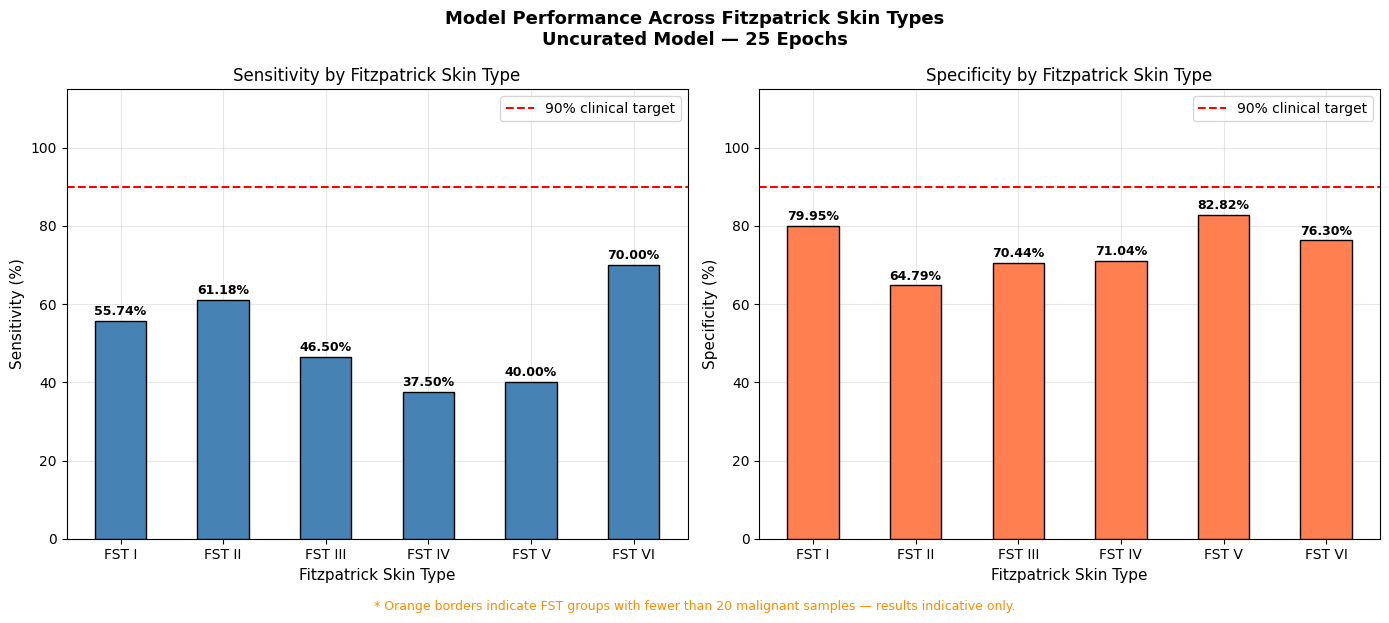

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done — fst_results.csv and fst_performance.png downloaded.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from google.colab import drive, files
import zipfile
import os

drive.mount('/content/drive')

# ── Unzip dataset if not already extracted ──────────────────────────────
extract_path = '/content/Skin_type_test'
if not os.path.exists(extract_path):
    print('Unzipping dataset...')
    with zipfile.ZipFile('/content/drive/MyDrive/Skin_type_test.zip', 'r') as z:
        z.extractall(extract_path)
    print('Unzipped.')
else:
    print('Dataset already extracted.')

# ── Verify folders ──────────────────────────────────────────────────────
print('\nVerifying folders...')
all_found = True
for folder in ['Benign', 'Malignant']:
    for fst in ['1', '2', '3', '4', '5']:
        path = os.path.join('/content/Skin_type_test/Skin type test', folder, fst)
        count = len(os.listdir(path)) if os.path.exists(path) else 'NOT FOUND'
        print(f'  {folder}/{fst}: {count}')
        if count == 'NOT FOUND':
            all_found = False

if not all_found:
    print('\nERROR: Some folders not found — check zip structure before continuing.')
else:
    print('\nAll folders verified.')

# ── Config ─────────────────────────────────────────────────────────────
UNCURATED_MODEL_PATH = '/content/drive/MyDrive/cnn_uncurated.keras'
DATASET_DIR          = '/content/Skin_type_test/Skin type test'
FST6_MALIGNANT_DIR   = '/content/drive/MyDrive/FST6_malignant'
IMG_SIZE             = (128, 128)
FST_TYPES            = ['1', '2', '3', '4', '5', '6']
FST_LABELS           = ['FST I', 'FST II', 'FST III', 'FST IV', 'FST V', 'FST VI']

# ── Load model ──────────────────────────────────────────────────────────
print('\nLoading model...')
model = load_model(UNCURATED_MODEL_PATH)
print('Model loaded.\n')

# ── Helper — batch predict all images in a folder ───────────────────────
def predict_folder(folder_path, label):
    if not os.path.exists(folder_path):
        print(f'  WARNING: folder not found — {folder_path}')
        return np.array([]), np.array([])

    image_files = [f for f in os.listdir(folder_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

    if len(image_files) == 0:
        print(f'  WARNING: no images found in {folder_path}')
        return np.array([]), np.array([])

    print(f'  Found {len(image_files)} images in {os.path.basename(folder_path)}')

    batch = []
    for img_file in image_files:
        try:
            img = load_img(os.path.join(folder_path, img_file), target_size=IMG_SIZE)
            arr = img_to_array(img) / 255.0
            batch.append(arr)
        except Exception as e:
            print(f'  Skipping {img_file}: {e}')
            continue

    if len(batch) == 0:
        return np.array([]), np.array([])

    batch_array = np.array(batch)
    batch_probs = model.predict(batch_array, batch_size=32, verbose=1).ravel()

    return batch_probs, np.full(len(batch_probs), label)

# ── Run per FST group ───────────────────────────────────────────────────
results = []

for fst, fst_label in zip(FST_TYPES, FST_LABELS):
    print(f'\n════ Processing {fst_label} ════')

    benign_dir = os.path.join(DATASET_DIR, 'Benign', fst)

    if fst == '6':
        malignant_dir = FST6_MALIGNANT_DIR
    else:
        malignant_dir = os.path.join(DATASET_DIR, 'Malignant', fst)

    print('Loading benign images...')
    ben_probs, ben_labels = predict_folder(benign_dir, 0)

    print('Loading malignant images...')
    mal_probs, mal_labels = predict_folder(malignant_dir, 1)

    if len(ben_labels) == 0 and len(mal_labels) == 0:
        print(f'  Skipping {fst_label} — no images found')
        continue

    probs  = np.concatenate([ben_probs,  mal_probs])
    labels = np.concatenate([ben_labels, mal_labels])
    preds  = (probs >= 0.5).astype(int)

    tp = np.sum((preds == 1) & (labels == 1))
    tn = np.sum((preds == 0) & (labels == 0))
    fp = np.sum((preds == 1) & (labels == 0))
    fn = np.sum((preds == 0) & (labels == 1))

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else None
    specificity = tn / (tn + fp) if (tn + fp) > 0 else None
    accuracy    = (tp + tn) / len(labels) if len(labels) > 0 else None
    precision   = tp / (tp + fp) if (tp + fp) > 0 else None
    f1          = (2 * precision * sensitivity / (precision + sensitivity)
                   if precision and sensitivity and (precision + sensitivity) > 0 else None)

    note = (f'Low malignant sample size (n={len(mal_labels)}) — results indicative only'
            if len(mal_labels) < 20 else '')

    results.append({
        'FST':         fst_label,
        'N Benign':    len(ben_labels),
        'N Malignant': len(mal_labels),
        'Total':       len(labels),
        'Sensitivity': round(sensitivity * 100, 2) if sensitivity is not None else None,
        'Specificity': round(specificity * 100, 2) if specificity is not None else None,
        'Accuracy':    round(accuracy    * 100, 2) if accuracy    is not None else None,
        'Precision':   round(precision   * 100, 2) if precision   is not None else None,
        'F1 Score':    round(f1, 4)                if f1          is not None else None,
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'Note': note
    })

    sens_str = f'{sensitivity*100:.1f}%' if sensitivity is not None else 'N/A'
    spec_str = f'{specificity*100:.1f}%' if specificity is not None else 'N/A'
    print(f'  Sensitivity: {sens_str} | Specificity: {spec_str} | '
          f'N_ben={len(ben_labels)} N_mal={len(mal_labels)}')
    if note:
        print(f'  NOTE: {note}')

# ── Results table ───────────────────────────────────────────────────────
df = pd.DataFrame(results)
print('\n════ FULL RESULTS ════')
print(df.to_string(index=False))
df.to_csv('fst_results.csv', index=False)

# ── Plot ────────────────────────────────────────────────────────────────
df_plot = df.copy()
df_plot['Sensitivity'] = pd.to_numeric(df_plot['Sensitivity'], errors='coerce')
df_plot['Specificity'] = pd.to_numeric(df_plot['Specificity'], errors='coerce')

x = np.arange(len(df_plot))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Performance Across Fitzpatrick Skin Types\nUncurated Model — 25 Epochs',
             fontsize=13, fontweight='bold')

# ── Sensitivity plot ────────────────────────────────────────────────────
sens_bars = axes[0].bar(x, df_plot['Sensitivity'].fillna(0), width=0.5,
                        color='steelblue', edgecolor='black', zorder=3)
axes[0].axhline(y=90, color='red', linestyle='--', lw=1.5, label='90% clinical target')
for i, (v, row) in enumerate(zip(df_plot['Sensitivity'], df_plot.itertuples())):
    label = f'{v:.2f}%' if not np.isnan(v) else 'N/A'
    ypos  = v + 1.5 if not np.isnan(v) else 2
    axes[0].text(i, ypos, label, ha='center', fontsize=9, fontweight='bold')
    if row._asdict().get('N Malignant', 100) < 20:
        sens_bars[i].set_edgecolor('orange')
        sens_bars[i].set_linewidth(2.5)
axes[0].set_xlabel('Fitzpatrick Skin Type', fontsize=11)
axes[0].set_ylabel('Sensitivity (%)', fontsize=11)
axes[0].set_title('Sensitivity by Fitzpatrick Skin Type', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_plot['FST'])
axes[0].set_ylim([0, 115])
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, zorder=0)

# ── Specificity plot ────────────────────────────────────────────────────
spec_bars = axes[1].bar(x, df_plot['Specificity'].fillna(0), width=0.5,
                        color='coral', edgecolor='black', zorder=3)
axes[1].axhline(y=90, color='red', linestyle='--', lw=1.5, label='90% clinical target')
for i, (v, row) in enumerate(zip(df_plot['Specificity'], df_plot.itertuples())):
    label = f'{v:.2f}%' if not np.isnan(v) else 'N/A'
    ypos  = v + 1.5 if not np.isnan(v) else 2
    axes[1].text(i, ypos, label, ha='center', fontsize=9, fontweight='bold')
    if row._asdict().get('N Malignant', 100) < 20:
        spec_bars[i].set_edgecolor('orange')
        spec_bars[i].set_linewidth(2.5)
axes[1].set_xlabel('Fitzpatrick Skin Type', fontsize=11)
axes[1].set_ylabel('Specificity (%)', fontsize=11)
axes[1].set_title('Specificity by Fitzpatrick Skin Type', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_plot['FST'])
axes[1].set_ylim([0, 115])
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, zorder=0)

fig.text(0.5, -0.02,
         '* Orange borders indicate FST groups with fewer than 20 malignant samples — results indicative only.',
         ha='center', fontsize=9, color='darkorange')

plt.tight_layout()
plt.savefig('fst_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Download ────────────────────────────────────────────────────────────
files.download('fst_results.csv')
files.download('fst_performance.png')
print('\nDone — fst_results.csv and fst_performance.png downloaded.')

In [ ]:
import shutil
import os

# Force copy curated dataset
if os.path.exists('/content/dataset_curated'):
    shutil.rmtree('/content/dataset_curated')

shutil.copytree('/content/drive/MyDrive/dataset_curated', '/content/dataset_curated')
print('Done')

# Verify
for folder in ['Training', 'Validation']:
    path = f'/content/dataset_curated/{folder}'
    if os.path.exists(path):
        classes = os.listdir(path)
        print(f'{folder}: {classes}')
    else:
        print(f'{folder}: NOT FOUND')

Done
Training: ['Benign', 'Malignant']
Validation: ['Benign', 'Malignant']


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive, files
import os, shutil

drive.mount('/content/drive')

# ── Copy datasets local ─────────────────────────────────────
if not os.path.exists('/content/dataset_uncurated'):
    shutil.copytree('/content/drive/MyDrive/dataset_uncurated', '/content/dataset_uncurated')
if not os.path.exists('/content/dataset_curated'):
    shutil.copytree('/content/drive/MyDrive/dataset_curated', '/content/dataset_curated')

# ── Config ──────────────────────────────────────────────────
UNCURATED_MODEL = '/content/drive/MyDrive/cnn_uncurated.keras'
CURATED_MODEL   = '/content/drive/MyDrive/cnn_curated.keras'
UNCURATED_DIR   = '/content/dataset_uncurated'
CURATED_DIR     = '/content/dataset_curated'
IMG_SIZE        = (128, 128)
BATCH_SIZE      = 32

# ── Generators ──────────────────────────────────────────────
val_datagen = ImageDataGenerator(rescale=1./255)

unc_val = val_datagen.flow_from_directory(
    f'{UNCURATED_DIR}/Validation',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)

cur_val = val_datagen.flow_from_directory(
    f'{CURATED_DIR}/Validation',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)

# ── Load models and predict ─────────────────────────────────
print('Loading models...')
model_unc = load_model(UNCURATED_MODEL)
model_cur = load_model(CURATED_MODEL)

print('Predicting uncurated...')
unc_val.reset()
unc_probs  = model_unc.predict(unc_val, verbose=1).ravel()
unc_labels = unc_val.classes

print('Predicting curated...')
cur_val.reset()
cur_probs  = model_cur.predict(cur_val, verbose=1).ravel()
cur_labels = cur_val.classes

# ════════════════════════════════════════════════════════════
# 1. ROC CURVE DATA
# ════════════════════════════════════════════════════════════
print('\nGenerating ROC data...')

fpr_u, tpr_u, thresh_roc_u = roc_curve(unc_labels, unc_probs)
fpr_c, tpr_c, thresh_roc_c = roc_curve(cur_labels, cur_probs)

auc_u = auc(fpr_u, tpr_u)
auc_c = auc(fpr_c, tpr_c)

df_roc_unc = pd.DataFrame({
    'Threshold':          thresh_roc_u,
    'False Positive Rate': fpr_u,
    'True Positive Rate':  tpr_u,
})
df_roc_cur = pd.DataFrame({
    'Threshold':          thresh_roc_c,
    'False Positive Rate': fpr_c,
    'True Positive Rate':  tpr_c,
})

print(f'Uncurated AUC: {auc_u:.4f}')
print(f'Curated   AUC: {auc_c:.4f}')

# ════════════════════════════════════════════════════════════
# 2. PRECISION-RECALL CURVE DATA
# ════════════════════════════════════════════════════════════
print('\nGenerating Precision-Recall data...')

prec_u, rec_u, thresh_pr_u = precision_recall_curve(unc_labels, unc_probs)
prec_c, rec_c, thresh_pr_c = precision_recall_curve(cur_labels, cur_probs)

ap_u = average_precision_score(unc_labels, unc_probs)
ap_c = average_precision_score(cur_labels, cur_probs)

df_pr_unc = pd.DataFrame({
    'Precision': prec_u,
    'Recall':    rec_u,
    'Threshold': np.append(thresh_pr_u, np.nan),
})
df_pr_cur = pd.DataFrame({
    'Precision': prec_c,
    'Recall':    rec_c,
    'Threshold': np.append(thresh_pr_c, np.nan),
})

print(f'Uncurated AP: {ap_u:.4f}')
print(f'Curated   AP: {ap_c:.4f}')

# ════════════════════════════════════════════════════════════
# 3. THRESHOLD ANALYSIS DATA
# ════════════════════════════════════════════════════════════
print('\nGenerating threshold analysis data...')

thresholds = np.arange(0.05, 1.0, 0.05)

def threshold_metrics(probs, labels, thresholds):
    rows = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tp = np.sum((preds == 1) & (labels == 1))
        tn = np.sum((preds == 0) & (labels == 0))
        fp = np.sum((preds == 1) & (labels == 0))
        fn = np.sum((preds == 0) & (labels == 1))
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1   = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0
        acc  = (tp + tn) / len(labels)
        rows.append({
            'Threshold':   round(t, 2),
            'Sensitivity': round(sens * 100, 2),
            'Specificity': round(spec * 100, 2),
            'Precision':   round(prec * 100, 2),
            'F1 Score':    round(f1, 4),
            'Accuracy':    round(acc * 100, 2),
            'TP': int(tp), 'TN': int(tn),
            'FP': int(fp), 'FN': int(fn),
        })
    return pd.DataFrame(rows)

df_thresh_unc = threshold_metrics(unc_probs, unc_labels, thresholds)
df_thresh_cur = threshold_metrics(cur_probs, cur_labels, thresholds)

# ════════════════════════════════════════════════════════════
# EXPORT TO EXCEL
# ════════════════════════════════════════════════════════════
print('\nExporting to Excel...')

output_path = '/content/drive/MyDrive/graph_raw_data_25_epochs.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    # ROC
    df_roc_unc.to_excel(writer, sheet_name='ROC Uncurated',   index=False)
    df_roc_cur.to_excel(writer, sheet_name='ROC Curated',     index=False)

    # PR
    df_pr_unc.to_excel(writer, sheet_name='PR Uncurated',     index=False)
    df_pr_cur.to_excel(writer, sheet_name='PR Curated',       index=False)

    # Threshold
    df_thresh_unc.to_excel(writer, sheet_name='Threshold Uncurated', index=False)
    df_thresh_cur.to_excel(writer, sheet_name='Threshold Curated',   index=False)

    # Summary
    summary = pd.DataFrame({
        'Metric':    ['AUC', 'Average Precision'],
        'Uncurated': [round(auc_u, 4), round(ap_u, 4)],
        'Curated':   [round(auc_c, 4), round(ap_c, 4)],
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

files.download(output_path)
print('\nDone — graph_raw_data_25_epochs.xlsx downloaded.')
print(f'\nSummary:')
print(f'  Uncurated AUC: {auc_u:.4f} | AP: {ap_u:.4f}')
print(f'  Curated   AUC: {auc_c:.4f} | AP: {ap_c:.4f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1038 images belonging to 2 classes.
Found 976 images belonging to 2 classes.
Loading models...
Predicting uncurated...
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 276ms/step
Predicting curated...
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 522ms/step

Generating ROC data...
Uncurated AUC: 0.9091
Curated   AUC: 0.8934

Generating Precision-Recall data...
Uncurated AP: 0.9378
Curated   AP: 0.8384

Generating threshold analysis data...

Exporting to Excel...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done — graph_raw_data_25_epochs.xlsx downloaded.

Summary:
  Uncurated AUC: 0.9091 | AP: 0.9378
  Curated   AUC: 0.8934 | AP: 0.8384
